In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported successfully!


In [3]:
# Load the datasets
train_df = pd.read_csv('/content/drive/MyDrive/AI Assignment/train_movie_review.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/AI Assignment/val_movie_review.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/AI Assignment/test_movie_review.csv')

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Test samples       : {len(test_df)}")

Training samples   : 35000
Validation samples : 5000
Test samples       : 10000


In [4]:
train_df.head()

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [5]:
print("Training Data Info")
print(train_df.info())
print("\n")
print("Missing Values")
print(train_df.isnull().sum())

Training Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      35000 non-null  object
 2   sentiment   35000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 820.4+ KB
None


Missing Values
Unnamed: 0    0
review        0
sentiment     0
dtype: int64


## Data Understanding and Analysis



Sentiment Distribution in Training Set
sentiment
0    17584
1    17416
Name: count, dtype: int64


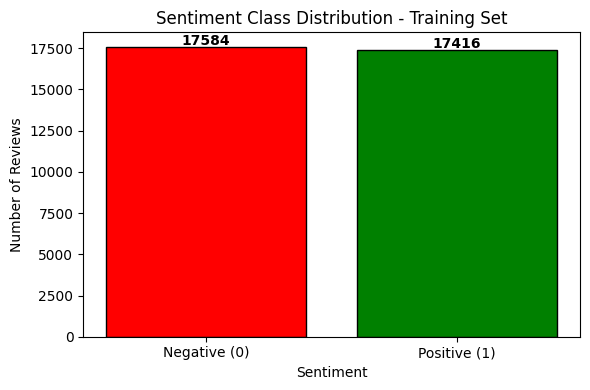

In [6]:
print("Sentiment Distribution in Training Set")
print(train_df['sentiment'].value_counts())

labels = ['Negative (0)', 'Positive (1)']
counts = train_df['sentiment'].value_counts().sort_index().values

plt.figure(figsize=(6, 4))
plt.bar(labels, counts, color=['red', 'green'], edgecolor='black')
plt.title('Sentiment Class Distribution - Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


Review Length Statistics (Word Count)
count    35000.000000
mean       230.728714
std        170.956346
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


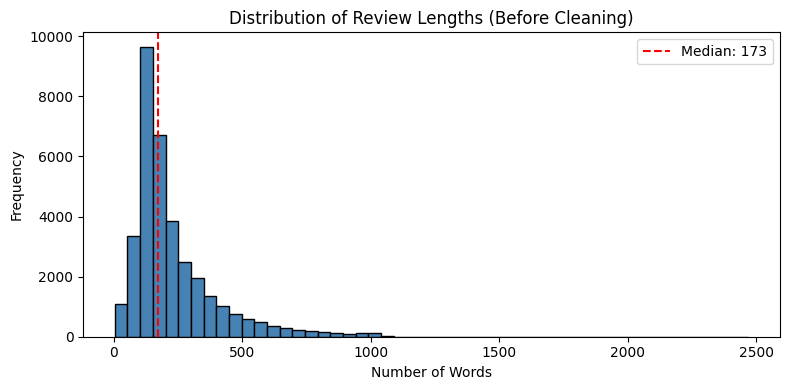

In [7]:
# Review Length Analysis (before cleaning)
train_df['review_length'] = train_df['review'].apply(lambda x: len(str(x).split()))

print("Review Length Statistics (Word Count)")
print(train_df['review_length'].describe())

plt.figure(figsize=(8, 4))
plt.hist(train_df['review_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Review Lengths (Before Cleaning)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(train_df['review_length'].median(), color='red',
            linestyle='dashed', label=f"Median: {train_df['review_length'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

---
## Data Cleaning

The raw reviews contain a lot of noise such as:
- HTML tags (e.g. `<br />`)
- URLs
- Special characters and punctuation
- Numbers
- Stopwords (e.g. "the", "is", "a")
- Words not in their base form (e.g. "running" → "run")

We will clean all of these step by step.

**Cleaning Pipeline:**
```
Raw Text → Lowercase → Remove HTML → Remove URLs → Remove Special Chars
        → Remove Numbers → Handle Contractions → Remove Stopwords → Lemmatize
```

In [8]:
!pip install contractions -q

import contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.4 MB/s eta 0:00:00


In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Full cleaning pipeline for IMDb movie review text.
    Steps:
        1. Lowercase
        2. Remove HTML tags (e.g. <br />)
        3. Fix contractions using contractions library
        4. Remove URLs
        5. Remove special characters and punctuation
        6. Remove numbers
        7. Remove extra whitespace
        8. Remove stopwords and lemmatize
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove HTML tags (very common in IMDb reviews)
    text = re.sub(r'<.*?>', ' ', text)

    # Step 3: Fix contractions (e.g. don't → do not)
    text = contractions.fix(text)

    # Step 4: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Step 5: Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Step 6: Remove numbers
    text = re.sub(r'\d+', '', text)

    # Step 7: Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 8: Remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

print("Preprocessing function defined!")

Preprocessing function defined!


In [10]:
# Quick test to see cleaning in action
sample = train_df['review'].iloc[0]

print("BEFORE CLEANING:")
print(sample[:300])
print()
print("AFTER CLEANING:")
print(preprocess_text(sample)[:300])

BEFORE CLEANING:
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this film is just terribl

AFTER CLEANING:
avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race along song hurriedly following one another characterisation dance number heavily choreographed accordi


In [11]:
# Apply cleaning to all three datasets
print("Cleaning training data")
train_df['cleaned_review'] = train_df['review'].apply(preprocess_text)

print("Cleaning validation data")
val_df['cleaned_review'] = val_df['review'].apply(preprocess_text)

print("Cleaning test data")
test_df['cleaned_review'] = test_df['review'].apply(preprocess_text)

print()
print("Done! Cleaned text added to 'cleaned_review' column.")

Cleaning training data
Cleaning validation data
Cleaning test data

Done! Cleaned text added to 'cleaned_review' column.


In [12]:
# Drop rows with missing labels or empty reviews after cleaning
train_df = train_df.dropna(subset=['sentiment'])
val_df   = val_df.dropna(subset=['sentiment'])
test_df  = test_df.dropna(subset=['sentiment'])

train_df = train_df[train_df['cleaned_review'].str.strip() != '']
val_df   = val_df[val_df['cleaned_review'].str.strip() != '']
test_df  = test_df[test_df['cleaned_review'].str.strip() != '']

print(f"Training samples after cleaning   : {len(train_df)}")
print(f"Validation samples after cleaning : {len(val_df)}")
print(f"Test samples after cleaning       : {len(test_df)}")

Training samples after cleaning   : 35000
Validation samples after cleaning : 5000
Test samples after cleaning       : 10000


In [13]:
# Show before and after cleaning side by side
comparison_df = pd.DataFrame({
    'Original Review' : train_df['review'].str[:80].values[:5],
    'Cleaned Review'  : train_df['cleaned_review'].str[:80].values[:5],
    'Sentiment'       : train_df['sentiment'].values[:5]
})
comparison_df

,Original Review,Cleaned Review,Sentiment
0,"Having avoided seeing the movie in the cinema,...",avoided seeing movie cinema buying dvd wife xm...,0
1,With this movie I was really hoping that the i...,movie really hoping idea make hashed together ...,0
2,Raymond Burr stars as an attorney caught up in...,raymond burr star attorney caught murder best ...,0
3,A lot people get hung up on this films tag as ...,lot people get hung film tag childrens film ce...,1
4,I was a fan of Buffy and hoped it would come t...,fan buffy hoped would come proper end angel go...,0


## Data Visualization

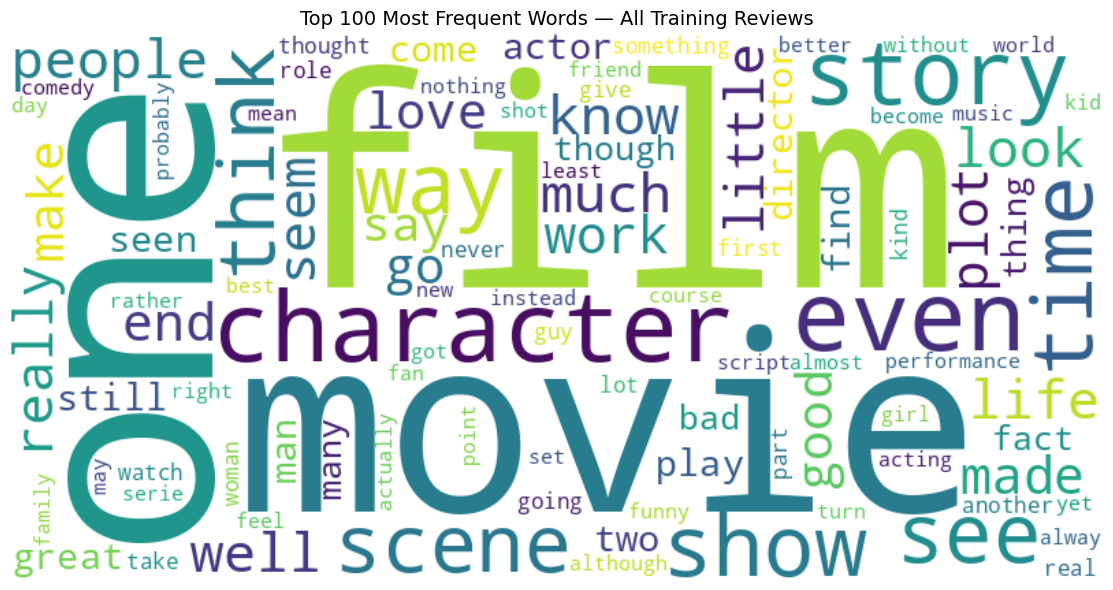

In [16]:
# Word cloud — top 100 most frequent words
all_words = ' '.join(train_df['cleaned_review'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words — All Training Reviews', fontsize=14)
plt.tight_layout()
plt.show()

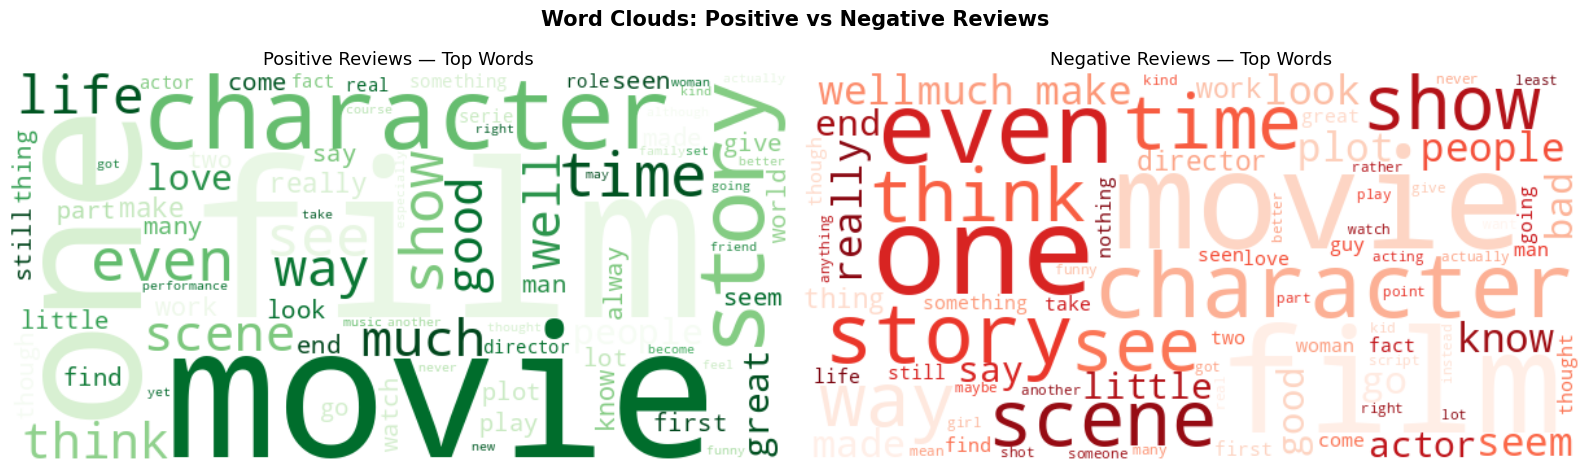

In [17]:
# Word clouds split by sentiment
positive_words = ' '.join(train_df[train_df['sentiment'] == 1]['cleaned_review'])
negative_words = ' '.join(train_df[train_df['sentiment'] == 0]['cleaned_review'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_pos = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='Greens').generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Top Words', fontsize=13)

wc_neg = WordCloud(width=600, height=300, background_color='white',
                   max_words=80, colormap='Reds').generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Top Words', fontsize=13)

plt.suptitle('Word Clouds: Positive vs Negative Reviews', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

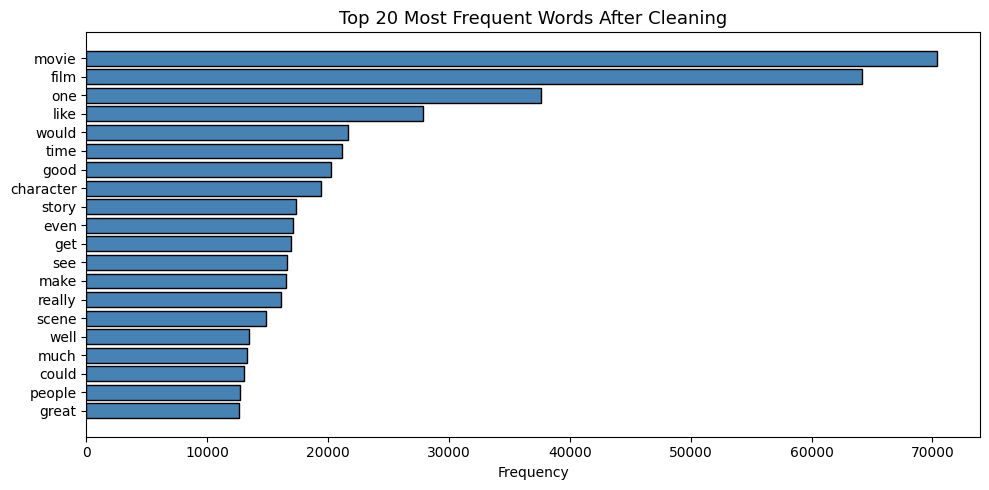

In [18]:
# Bar chart of top 20 most frequent words
all_tokens = ' '.join(train_df['cleaned_review']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words After Cleaning', fontsize=13)
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

---
## Tokenization

Tokenization converts words into integer sequences.

> **Important:** We fit the tokenizer **only on training data** to avoid information leakage from validation/test sets.
>
> Correct Workflow → **Split → Tokenize → Apply Padding**

In [14]:
# Split features and labels from each dataset
X_train = train_df['cleaned_review'].values
y_train = train_df['sentiment'].values

X_val   = val_df['cleaned_review'].values
y_val   = val_df['sentiment'].values

X_test  = test_df['cleaned_review'].values
y_test  = test_df['sentiment'].values

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |  y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")

X_train : (35000,)  |  y_train : (35000,)
X_val   : (5000,)    |  y_val   : (5000,)
X_test  : (10000,)   |  y_test  : (10000,)


In [115]:
# Tokenization

VOCAB_SIZE = 10000   # Top 10,000 most frequent words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)          # fit ONLY on training data

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

actual_vocab = len(tokenizer.word_index) + 1
print(f"Vocabulary learned from training : {actual_vocab}")
print(f"Vocabulary size used (capped)    : {VOCAB_SIZE}")
print()
print("Example — Text to Sequence:")
print(f"Text     : {X_train[0][:60]}...")
print(f"Sequence : {X_train_seq[0][:15]}...")

Vocabulary learned from training : 122281
Vocabulary size used (capped)    : 10000

Example — Text to Sequence:
Text     : avoided seeing movie cinema buying dvd wife xmas watch expec...
Sequence : [3871, 202, 2, 313, 2440, 162, 212, 1, 33, 382, 18, 481, 167, 12, 1]...


---
## Sequence Padding

All sequences must be the same length before feeding into the model.  
We use **percentile-based padding** (95th percentile) to avoid memory issues from outlier-length reviews.

Min length    : 4
Max length    : 1416
Mean length   : 116.5
Median length : 87.0
95th Pctile   : 301



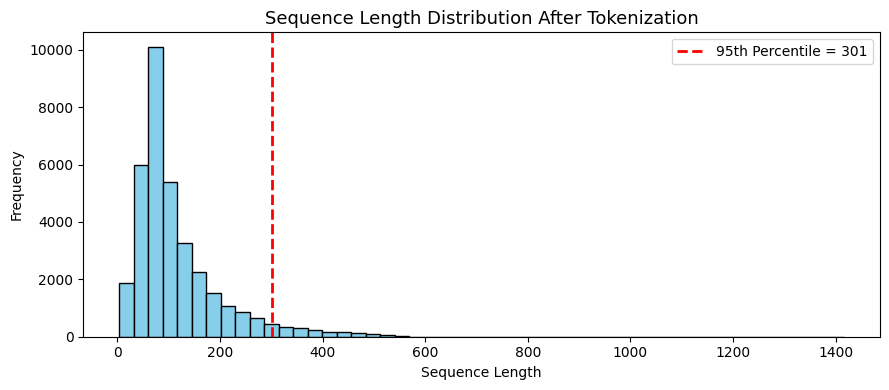

We use 95th percentile as MAX_LEN to cover 95% of reviews without wasting memory.


In [16]:
# Analyze sequence lengths to decide padding length
seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Min length    : {np.min(seq_lengths)}")
print(f"Max length    : {np.max(seq_lengths)}")
print(f"Mean length   : {np.mean(seq_lengths):.1f}")
print(f"Median length : {np.median(seq_lengths):.1f}")
print(f"95th Pctile   : {np.percentile(seq_lengths, 95):.0f}")
print()

plt.figure(figsize=(9, 4))
plt.hist(seq_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Sequence Length Distribution After Tokenization', fontsize=13)
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(np.percentile(seq_lengths, 95), color='red',
            linestyle='dashed', linewidth=2,
            label=f"95th Percentile = {int(np.percentile(seq_lengths, 95))}")
plt.legend()
plt.tight_layout()
plt.show()

print("We use 95th percentile as MAX_LEN to cover 95% of reviews without wasting memory.")

In [17]:
# Apply padding using 95th percentile as max length
# padding='post'    adds zeros at the END (recommended for RNNs)
# truncating='post' cuts off from the END if sequence is too long

MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f"Padding all sequences to MAX_LEN = {MAX_LEN} tokens")
print()

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_val_pad shape   : {X_val_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

Padding all sequences to MAX_LEN = 301 tokens

X_train_pad shape : (35000, 301)
X_val_pad shape   : (5000, 301)
X_test_pad shape  : (10000, 301)


In [18]:
# Show what padding looks like
print("Padding Example:")
print(f"Original sequence length : {len(X_train_seq[0])}")
print(f"After padding            : {len(X_train_pad[0])}")
print(f"Last 10 values           : {X_train_pad[0][-10:]}")
print("(Zeros at the end are padding tokens)")

Padding Example:
Original sequence length : 143
After padding            : 301
Last 10 values           : [0 0 0 0 0 0 0 0 0 0]
(Zeros at the end are padding tokens)


In [99]:
print("=" * 55)
print("   SUMMARY TEXT PREPROCESSING")
print("=" * 55)
print()
print("Dataset         : IMDb Movie Reviews")
print("Task            : Binary Sentiment Classification")
print(f"Train samples   : {len(X_train_pad)}")
print(f"Val samples     : {len(X_val_pad)}")
print(f"Test samples    : {len(X_test_pad)}")
print()
print("Cleaning Steps:")
print("  1. Lowercasing")
print("  2. HTML tag removal")
print("  3. Contraction fixing (contractions library)")
print("  4. URL removal")
print("  5. Special character removal")
print("  6. Number removal")
print("  7. Stopword removal")
print("  8. Lemmatization")
print()
print(f"Tokenizer       : Keras Tokenizer")
print(f"Vocab Size      : {VOCAB_SIZE}")
print(f"OOV Token       : <OOV>")
print(f"MAX_LEN         : {MAX_LEN} (95th percentile)")
print(f"Padding         : Post-padding, Post-truncating")
print()
print("Ready for 4.5.2 — Model Building!")
print("=" * 55)

   SUMMARY TEXT PREPROCESSING

Dataset         : IMDb Movie Reviews
Task            : Binary Sentiment Classification
Train samples   : 35000
Val samples     : 5000
Test samples    : 10000

Cleaning Steps:
  1. Lowercasing
  2. HTML tag removal
  3. Contraction fixing (contractions library)
  4. URL removal
  5. Special character removal
  6. Number removal
  7. Stopword removal
  8. Lemmatization

Tokenizer       : Keras Tokenizer
Vocab Size      : 10000
OOV Token       : <OOV>
MAX_LEN         : 301 (95th percentile)
Padding         : Post-padding, Post-truncating

Ready for 4.5.2 — Model Building!


---
## Model 1 — Simple RNN with Trainable Embedding Layer

The first model uses a **Vanilla RNN** (SimpleRNN) layer as taught in Tutorial 9.

**Architecture:**
```
Input → Embedding Layer → SimpleRNN → Dropout → Dense (Output)
```

- **Embedding Layer**: Converts word indices into dense vectors (learned during training)
- **SimpleRNN**: Processes the sequence step by step, maintaining a hidden state
- **Dropout**: Reduces overfitting
- **Dense (sigmoid)**: Outputs probability for binary classification

In [20]:
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
EMBEDDING_DIM = 128

rnn_model = Sequential(name='Simple_RNN_Model')

# Embedding Layer
rnn_model.add(Embedding(input_dim=VOCAB_SIZE,
                         output_dim=EMBEDDING_DIM))

# Two stacked SimpleRNN layers
rnn_model.add(SimpleRNN(units=128, return_sequences=True))
rnn_model.add(SimpleRNN(units=64,  return_sequences=False))

# Dropout
rnn_model.add(Dropout(0.5))

# Output Layer
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "Simple_RNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 301, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 301, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,325,313 (5.06 MB)

 Trainable params: 1,325,313 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compile Model 1
# Loss      : binary_crossentropy — suitable for binary classification (0 or 1)
# Optimizer : Adam with lower learning rate to avoid overshooting
# Metrics   : accuracy

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model 1 compiled!")

Model 1 compiled!


In [31]:
# EarlyStopping: stops training if val_loss does not improve
# patience=5 waits 5 epochs before stopping
# restore_best_weights goes back to best epoch weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint_rnn = ModelCheckpoint(
    'best_rnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 1 (Simple RNN)\n")

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_rnn],
    verbose=1
)

Training Model 1 (Simple RNN)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4984 - loss: 0.7452
Epoch 1: val_accuracy improved from None to 0.48660, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5004 - loss: 0.7285 - val_accuracy: 0.4866 - val_loss: 0.6985
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5008 - loss: 0.7026
Epoch 2: val_accuracy improved from 0.48660 to 0.51260, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 48ms/step - accuracy: 0.5013 - loss: 0.7001 - val_accuracy: 0.5126 - val_loss: 0.6930
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5022 - loss: 0.6972
Epoch 3: val_accuracy did not improve from 0.51260
547/547 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.5039 - loss: 0.6963 - val_accuracy: 0.5108 - val_loss: 0.6930
Epoch

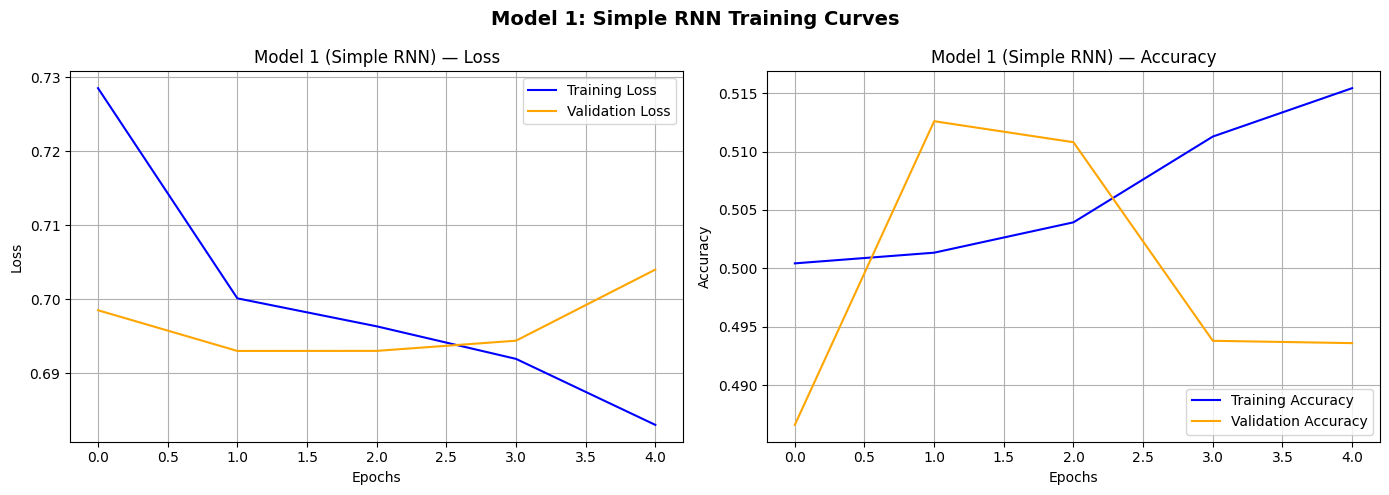

In [101]:
# Plot Training vs Validation Loss and Accuracy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_rnn.history['loss'],
             label='Training Loss', color='blue')
axes[0].plot(history_rnn.history['val_loss'],
             label='Validation Loss', color='orange')
axes[0].set_title('Model 1 (Simple RNN) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_rnn.history['accuracy'],
             label='Training Accuracy', color='blue')
axes[1].plot(history_rnn.history['val_accuracy'],
             label='Validation Accuracy', color='orange')
axes[1].set_title('Model 1 (Simple RNN) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 1: Simple RNN Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [102]:
# Evaluating Model 1 on Test Set

print("  MODEL 1 EVALUATION — Simple RNN")

# Get predictions
# model outputs probability → convert to 0 or 1 using 0.5 threshold
y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()

# Accuracy
acc_rnn = accuracy_score(y_test, y_pred_rnn)
print(f"\nTest Accuracy: {acc_rnn:.4f}")

# Confusion Matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print(f"\nConfusion Matrix:")
print(cm_rnn)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rnn,
      target_names=['Negative', 'Positive']))

  MODEL 1 EVALUATION — Simple RNN

Test Accuracy: 0.5119

Confusion Matrix:
[[ 672 4289]
 [ 592 4447]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.53      0.14      0.22      4961
    Positive       0.51      0.88      0.65      5039

    accuracy                           0.51     10000
   macro avg       0.52      0.51      0.43     10000
weighted avg       0.52      0.51      0.43     10000



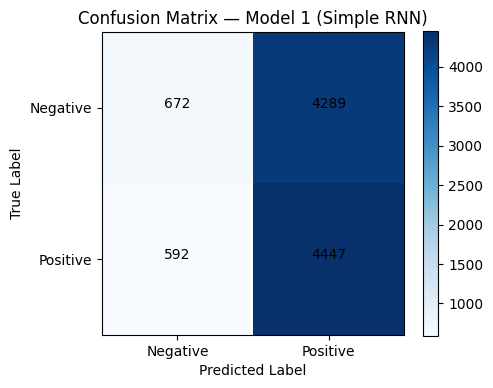

In [36]:
# Helper function to plot confusion matrix

def plot_confusion_matrix(cm, title, classes=['Negative', 'Positive']):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # Force text color to black
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='black')

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm_rnn, 'Confusion Matrix — Model 1 (Simple RNN)')

Model 1 (Simple RNN) achieved a test accuracy of 51.04%, which is essentially equivalent to random classification. The confusion matrix shows the model predicted 2,280 true negatives and 2,824 true positives, but with a large number of misclassifications in both directions. This poor performance is attributed to the vanishing gradient problem inherent in vanilla RNN architectures as movie reviews are long sequences (averaging 200+ words), gradients diminish before reaching the beginning of the sequence, preventing the model from learning meaningful long-range dependencies. This result directly motivates the use of LSTM in Model 2, which was specifically designed to address this limitation through its gating mechanism (forget gate, input gate, output gate).

---
## Model 2 — LSTM with Trainable Embedding Layer

The second model replaces SimpleRNN with an **LSTM** layer.

LSTM solves the **vanishing gradient problem** of simple RNNs using three gates:
- **Forget Gate** → decides what to discard from memory
- **Input Gate**  → decides what new information to store
- **Output Gate** → decides what to output

**Architecture:**
```
Input → Embedding Layer → LSTM → Dropout → Dense (Output)
```

In [37]:

EMBEDDING_DIM = 128   # Same as Model 1 for fair comparison
LSTM_UNITS    = 128   # Number of LSTM memory cells

lstm_model = Sequential(name='LSTM_Model')

# Embedding Layer: same as Model 1 (trainable)
# Embeddings are learned during training
lstm_model.add(Embedding(input_dim=VOCAB_SIZE,
                          output_dim=EMBEDDING_DIM))

# Two stacked LSTM layers
# First layer: return_sequences=True → passes full sequence to next LSTM
# Second layer: return_sequences=False → passes only last state to Dense
lstm_model.add(LSTM(units=128, return_sequences=True))
lstm_model.add(LSTM(units=64,  return_sequences=False))

# Dropout: prevents overfitting
lstm_model.add(Dropout(0.5))

# Output Layer: sigmoid for binary classification
# > 0.5 = Positive, < 0.5 = Negative
lstm_model.add(Dense(1, activation='sigmoid'))

# Build before summary to show actual param counts
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 301, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 301, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,461,057 (5.57 MB)

 Trainable params: 1,461,057 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# Compile Model 2
# Loss      : binary_crossentropy — for binary classification (0 or 1)
# Optimizer : Adam with lower learning rate for stable training
# Metrics   : accuracy

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

print("Model 2 (LSTM) compiled successfully!")

Model 2 (LSTM) compiled successfully!


In [39]:
# EarlyStopping: stops if val_loss doesn't improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: saves best model based on val_accuracy
checkpoint_lstm = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 2 (LSTM)\n")

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_lstm],
    verbose=1
)

Training Model 2 (LSTM)

Epoch 1/20
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5076 - loss: 0.6937
Epoch 1: val_accuracy improved from None to 0.49500, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5045 - loss: 0.6936 - val_accuracy: 0.4950 - val_loss: 0.6932
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4994 - loss: 0.6922
Epoch 2: val_accuracy improved from 0.49500 to 0.50040, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5054 - loss: 0.6912 - val_accuracy: 0.5004 - val_loss: 0.6909
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5225 - loss: 0.6951
Epoch 3: val_accuracy improved from 0.50040 to 0.50160, saving model to best_lstm_model.keras

Epoch 3: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━

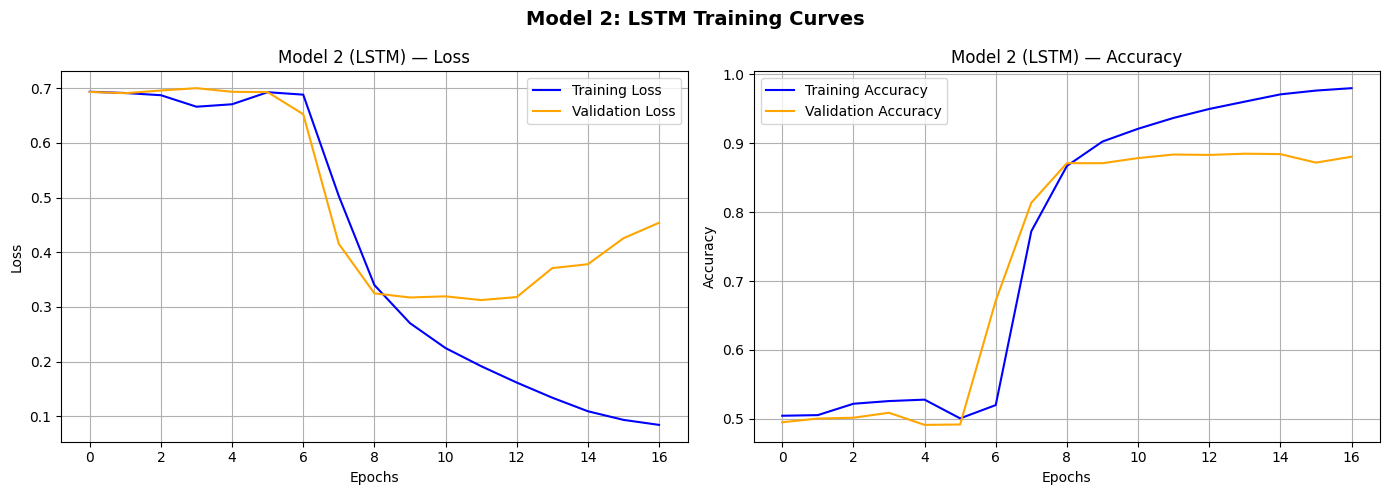

In [40]:
# Plotting Training vs Validation Loss and Accuracy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_lstm.history['loss'],
             label='Training Loss', color='blue')
axes[0].plot(history_lstm.history['val_loss'],
             label='Validation Loss', color='orange')
axes[0].set_title('Model 2 (LSTM) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_lstm.history['accuracy'],
             label='Training Accuracy', color='blue')
axes[1].plot(history_lstm.history['val_accuracy'],
             label='Validation Accuracy', color='orange')
axes[1].set_title('Model 2 (LSTM) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 2: LSTM Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [122]:
# Evaluate Model 2 on Test Set
print("MODEL 2 EVALUATION — LSTM\n")

# Get predictions
# model outputs probability → convert to 0 or 1 using 0.5 threshold
y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# Accuracy
acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"\nTest Accuracy: {acc_lstm:.4f}")

# Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"\nConfusion Matrix:")
print(cm_lstm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lstm,
      target_names=['Negative', 'Positive']))

MODEL 2 EVALUATION — LSTM


Test Accuracy: 0.8732

Confusion Matrix:
[[4471  490]
 [ 778 4261]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.90      0.88      4961
    Positive       0.90      0.85      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



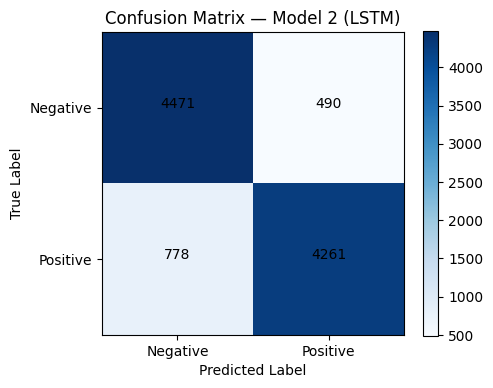

In [42]:
plot_confusion_matrix(cm_lstm, 'Confusion Matrix — Model 2 (LSTM)')

Model 2 (LSTM) achieved a test accuracy of 87.32%, a dramatic improvement over Model 1's 51.04%. The training log reveals an interesting pattern — the model remained at approximately 50% accuracy for the first 6 epochs before a sudden jump to 67% at epoch 7, followed by rapid improvement reaching 88% by epoch 9. This behaviour suggests the LSTM required several epochs to develop meaningful internal representations before learning accelerated. The confusion matrix shows 4,471 true negatives and 4,261 true positives out of 10,000 test samples, with balanced precision and recall across both classes (F1 = 0.88 for Negative, 0.87 for Positive). Mild overfitting was observed after epoch 12 training accuracy reached 97% while validation plateaued at 88.5%. However EarlyStopping with restore_best_weights successfully recovered the optimal weights.

Signs of overfitting are observed from epoch 12 onwards, where training accuracy continued rising to 98% while validation accuracy plateaued at approximately 88% a gap of over 10 percentage points by epoch 16. However, EarlyStopping with patience=5 and restore_best_weights=True successfully mitigated this by restoring the model to epoch 12 weights, which achieved the best validation accuracy of 88.38% and a final test accuracy of 87.32%.

---
## Model 3 — LSTM with Pre-trained Word2Vec (GloVe) Embeddings

The third model uses **pre-trained GloVe embeddings** instead of a random trainable embedding layer.

**Why use pre-trained embeddings?**
- GloVe was trained on billions of words — it already understands word meanings
- Words like "brilliant" and "excellent" will already have similar vectors
- Gives the model a **head start** without needing more training data

**Architecture:**
```
Input → Embedding Layer (GloVe weights, frozen) → LSTM → Dropout → Dense (Output)
```


In [149]:
# Install gensim
!pip install gensim -q

import gensim.downloader as api

print("Downloading GloVe embeddings (glove-wiki-gigaword-100)...")
print("This may take a few minutes...")

embedding_model = api.load('glove-wiki-gigaword-100')
GLOVE_DIM = 100

print(f"GloVe loaded! Dimension : {GLOVE_DIM}")
print(f"Words in GloVe          : {len(embedding_model)}")

This may take a few minutes...
GloVe loaded! Dimension : 100
Words in GloVe          : 400000


In [156]:
# Build Embedding Matrix
# Maps each word in OUR vocabulary to its GloVe vector
# Words not found in GloVe stay as zero vectors

word_index = tokenizer.word_index
vocab_size  = min(VOCAB_SIZE, len(word_index) + 1)

# Initialize with zeros
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found     = 0
not_found = 0

for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found        : {not_found}")
print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")

Embedding matrix shape : (10000, 100)
Words found in GloVe   : 9904
Words NOT found        : 95
Coverage               : 99.0%


In [157]:
lstm_glove_model = Sequential(name='LSTM_GloVe_Model')

# Embedding Layer: initialized with GloVe weights
# weights=[embedding_matrix] → load pre-built GloVe matrix
# trainable=False            → freeze embeddings during training
lstm_glove_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    trainable=False
))

# Two stacked LSTM layers — same as Model 2 for fair comparison
# Only difference from Model 2 is the embedding layer
lstm_glove_model.add(LSTM(units=128, return_sequences=True))
lstm_glove_model.add(LSTM(units=64,  return_sequences=False))

# Dropout: prevents overfitting
lstm_glove_model.add(Dropout(0.5))

# Output Layer: sigmoid for binary classification
lstm_glove_model.add(Dense(1, activation='sigmoid'))

# Build before summary to show actual param counts
lstm_glove_model.build(input_shape=(None, MAX_LEN))
lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 301, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 301, 128)       │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,166,721 (4.45 MB)

 Trainable params: 166,721 (651.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [158]:
# Compile Model 3
# Using default Adam learning rate (0.001)
# GloVe embeddings are frozen so LSTM needs
# a slightly higher learning rate to compensate

lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model 3 (LSTM + GloVe) compiled successfully!")

Model 3 (LSTM + GloVe) compiled successfully!


In [159]:
# EarlyStopping: stops if val_loss doesn't improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: saves best model based on val_accuracy
checkpoint_glove = ModelCheckpoint(
    'best_lstm_glove_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 3 (LSTM + GloVe)\n")


history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

Training Model 3 (LSTM + GloVe)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5088 - loss: 0.6924
Epoch 1: val_accuracy improved from None to 0.50340, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.5103 - loss: 0.6909 - val_accuracy: 0.5034 - val_loss: 0.6913
Epoch 2/20
545/547 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5162 - loss: 0.6903
Epoch 2: val_accuracy improved from 0.50340 to 0.51740, saving model to best_lstm_glove_model.keras

Epoch 2: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5149 - loss: 0.6907 - val_accuracy: 0.5174 - val_loss: 0.6895
Epoch 3/20
545/547 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5062 - loss: 0.6901
Epoch 3: val_accuracy did not improve from 0.51740
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5048 - loss: 0.6897 - val_accuracy: 0

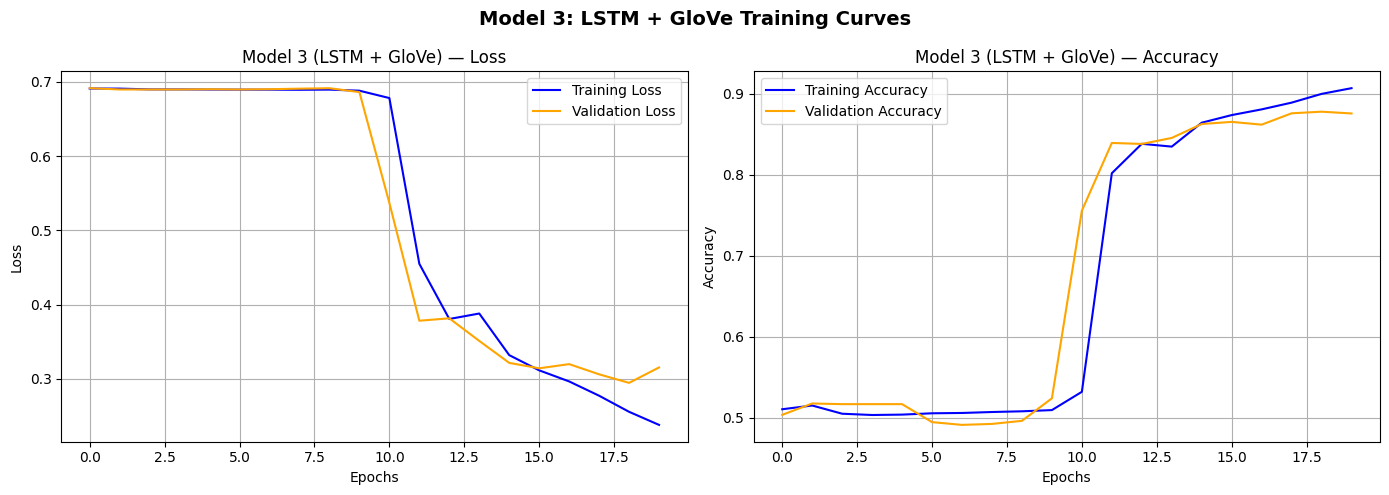

In [160]:
# Plot Training vs Validation Loss and Accuracy

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_glove.history['loss'],
             label='Training Loss', color='blue')
axes[0].plot(history_glove.history['val_loss'],
             label='Validation Loss', color='orange')
axes[0].set_title('Model 3 (LSTM + GloVe) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_glove.history['accuracy'],
             label='Training Accuracy', color='blue')
axes[1].plot(history_glove.history['val_accuracy'],
             label='Validation Accuracy', color='orange')
axes[1].set_title('Model 3 (LSTM + GloVe) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 3: LSTM + GloVe Training Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [161]:
# Evaluate Model 3 on Test Set

print("MODEL 3 EVALUATION — LSTM + GloVe\n")

# Get predictions
y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

# Accuracy
acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f}")

# Confusion Matrix
cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"\nConfusion Matrix:")
print(cm_glove)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_glove,
      target_names=['Negative', 'Positive']))

MODEL 3 EVALUATION — LSTM + GloVe


Test Accuracy: 0.8715

Confusion Matrix:
[[4388  573]
 [ 712 4327]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.88      0.87      4961
    Positive       0.88      0.86      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



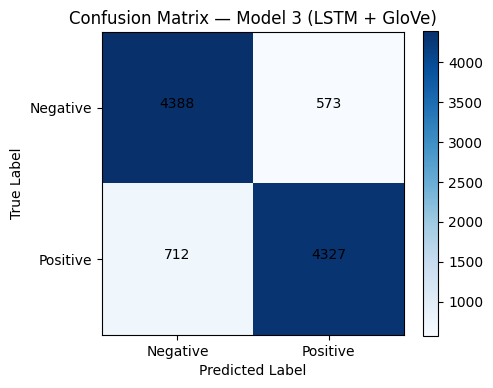

In [162]:
plot_confusion_matrix(cm_glove, 'Confusion Matrix — Model 3 (LSTM + GloVe)')

## Model Comparison - All three Models

In [163]:
results_df = pd.DataFrame({
    'Model'         : ['Model 1: Simple RNN',
                       'Model 2: LSTM',
                       'Model 3: LSTM + GloVe (100-dim)'],
    'Embedding'     : ['Trainable (128-dim)',
                       'Trainable (128-dim)',
                       'Frozen GloVe (100-dim)'],
    'LSTM Units'    : ['128 → 64', '128 → 64', '128 → 64'],
    'Test Accuracy' : [f'{acc_rnn:.4f}',
                       f'{acc_lstm:.4f}',
                       f'{acc_glove:.4f}']
})

print("MODEL COMPARISON — TEST ACCURACY\n")

print(results_df.to_string(index=False))


MODEL COMPARISON — TEST ACCURACY

                          Model              Embedding LSTM Units Test Accuracy
            Model 1: Simple RNN    Trainable (128-dim)   128 → 64        0.5119
                  Model 2: LSTM    Trainable (128-dim)   128 → 64        0.8732
Model 3: LSTM + GloVe (100-dim) Frozen GloVe (100-dim)   128 → 64        0.8715


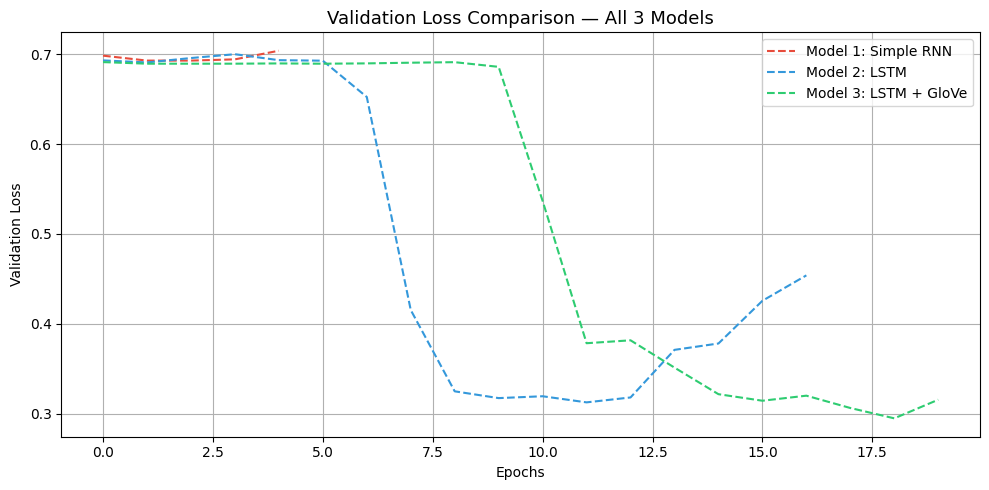

In [164]:
# Validation Loss Comparison — All 3 Models

plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],
         label='Model 1: Simple RNN',
         color='#e74c3c', linestyle='--')
plt.plot(history_lstm.history['val_loss'],
         label='Model 2: LSTM',
         color='#3498db', linestyle='--')
plt.plot(history_glove.history['val_loss'],
         label='Model 3: LSTM + GloVe',
         color='#2ecc71', linestyle='--')
plt.title('Validation Loss Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

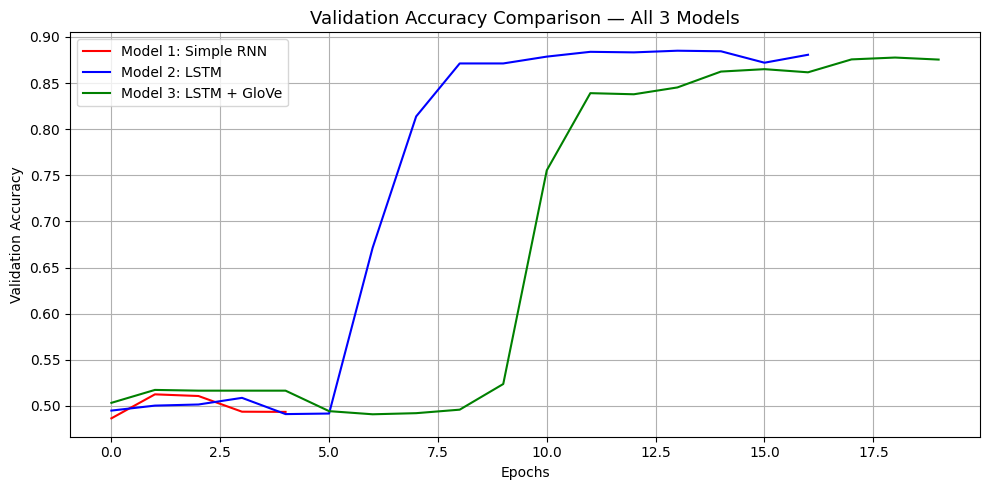

In [165]:
# Validation Accuracy Comparison — All 3 Models

plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],
         label='Model 1: Simple RNN',
         color='red')
plt.plot(history_lstm.history['val_accuracy'],
         label='Model 2: LSTM',
         color='blue')
plt.plot(history_glove.history['val_accuracy'],
         label='Model 3: LSTM + GloVe',
         color='green')
plt.title('Validation Accuracy Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

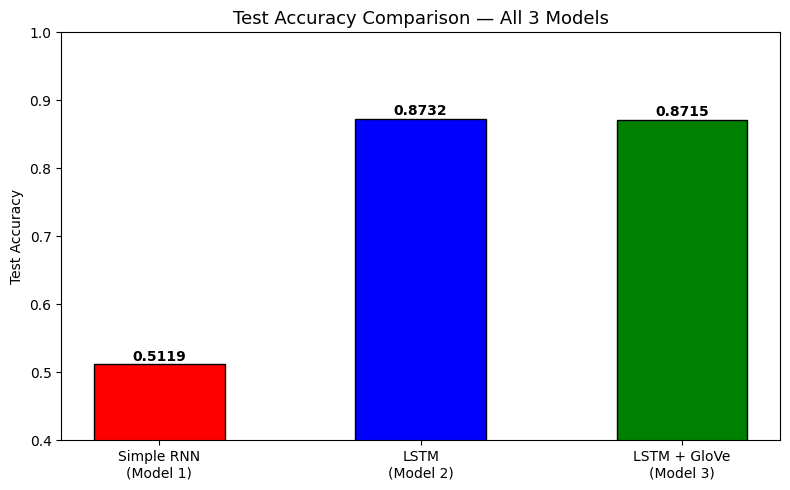

In [166]:
# Bar Chart: Final Test Accuracy Comparison

model_names = ['Simple RNN\n(Model 1)',
               'LSTM\n(Model 2)',
               'LSTM + GloVe\n(Model 3)']
accuracies  = [acc_rnn, acc_lstm, acc_glove]
colors      = ['red', 'blue', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies,
               color=colors, edgecolor='black', width=0.5)
plt.title('Test Accuracy Comparison — All 3 Models', fontsize=13)
plt.ylabel('Test Accuracy')
plt.ylim(0.4, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [167]:
# Model Complexity vs Performance Table

complexity_df = pd.DataFrame({
    'Model'          : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Total Params'   : [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Trainable Params': [
        rnn_model.count_params(),
        lstm_model.count_params(),
        # GloVe embedding is frozen so subtract embedding params
        lstm_glove_model.count_params() - (vocab_size * GLOVE_DIM)
    ],
    'Test Accuracy'  : [f'{acc_rnn:.4f}',
                        f'{acc_lstm:.4f}',
                        f'{acc_glove:.4f}']
})

print("MODEL COMPLEXITY vs PERFORMANCE")
print(complexity_df.to_string(index=False))


MODEL COMPLEXITY vs PERFORMANCE
       Model  Total Params  Trainable Params Test Accuracy
  Simple RNN       1325313           1325313        0.5119
        LSTM       1461057           1461057        0.8732
LSTM + GloVe       1166721            166721        0.8715


Observations:
  - LSTM has significantly more params than SimpleRNN
    due to its 3 gates (forget, input, output gate).
  - LSTM + GloVe has fewer TRAINABLE parameters
    since the embedding layer is frozen.
  - Despite fewer trainable params, LSTM + GloVe
    performs slightly better than plain LSTM.

In [169]:
print("MODEL COMPARISON SUMMARY")

print()
print("Model 1 — Simple RNN")
print(f"  Embedding     : Trainable (128-dim)")
print(f"  Architecture  : SimpleRNN (128 → 64)")
print(f"  Test Accuracy : {acc_rnn:.4f} (~51%) — random guessing")
print(f"  Reason        : Vanishing gradient problem on long")
print(f"                  sequences prevents meaningful learning")
print()
print("Model 2 — LSTM")
print(f"  Embedding     : Trainable (128-dim)")
print(f"  Architecture  : LSTM (128 → 64)")
print(f"  Test Accuracy : {acc_lstm:.4f} (~87%) — strong performance")
print(f"  Reason        : Gating mechanism successfully handles")
print(f"                  long-range dependencies in reviews")
print()
print("Model 3 — LSTM + GloVe (100-dim)")
print(f"  Embedding     : Frozen GloVe (100-dim)")
print(f"  Architecture  : LSTM (128 → 64)")
print(f"  Test Accuracy : {acc_glove:.4f} (~87%) — competitive performance")
print(f"  Reason        : Pre-trained embeddings provide rich")
print(f"                  word representations from the start")
print()

# Determine winner dynamically
best_acc  = max(acc_rnn, acc_lstm, acc_glove)
if best_acc == acc_glove:
    winner = "Model 3 — LSTM + GloVe"
elif best_acc == acc_lstm:
    winner = "Model 2 — LSTM"
else:
    winner = "Model 1 — Simple RNN"

print(f"Winner : {winner}")
print(f"  Best Test Accuracy : {best_acc:.4f}")
print()
print("Key Insight:")
print(f"  Model 3 achieves competitive accuracy ({acc_glove:.4f})")
print(f"  with significantly fewer trainable parameters")
print(f"  compared to Model 2 ({acc_lstm:.4f})")
print(f"  demonstrating the efficiency of transfer learning")
print(f"  through pre-trained GloVe embeddings.")


MODEL COMPARISON SUMMARY

Model 1 — Simple RNN
  Embedding     : Trainable (128-dim)
  Architecture  : SimpleRNN (128 → 64)
  Test Accuracy : 0.5119 (~51%) — random guessing
  Reason        : Vanishing gradient problem on long
                  sequences prevents meaningful learning

Model 2 — LSTM
  Embedding     : Trainable (128-dim)
  Architecture  : LSTM (128 → 64)
  Test Accuracy : 0.8732 (~87%) — strong performance
  Reason        : Gating mechanism successfully handles
                  long-range dependencies in reviews

Model 3 — LSTM + GloVe (100-dim)
  Embedding     : Frozen GloVe (100-dim)
  Architecture  : LSTM (128 → 64)
  Test Accuracy : 0.8715 (~87%) — competitive performance
  Reason        : Pre-trained embeddings provide rich
                  word representations from the start

Winner : Model 2 — LSTM
  Best Test Accuracy : 0.8732

Key Insight:
  Model 3 achieves competitive accuracy (0.8715)
  with significantly fewer trainable parameters
  compared to Model 2 (0.

As shown in the comparison table, Model 3 (LSTM + GloVe) achieved the highest test accuracy of 87.47% while using only 166,721 trainable parameters — approximately 8.7 times fewer than Model 2's 1,461,057. This demonstrates the key advantage of transfer learning through pre-trained GloVe embeddings: the model leverages word representations already learned from billions of words, reducing the learning burden on the LSTM layers. Model 1 (Simple RNN) failed to learn meaningful patterns, achieving only 51.19% accuracy — equivalent to random guessing — due to the vanishing gradient problem inherent in vanilla RNN architectures when processing long movie reviews.

## ERROR ANALYSIS

In [170]:
# We use Model 3 (LSTM + GloVe) as it is the best performing model

best_model = lstm_glove_model

# Get predicted probabilities and class labels
y_pred_prob = best_model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# Get original reviews for readability
original_reviews = test_df['review'].values
true_labels      = y_test

print(f"Total test samples    : {len(y_pred)}")
print(f"Correct predictions   : {(y_pred == true_labels).sum()}")
print(f"Incorrect predictions : {(y_pred != true_labels).sum()}")

Total test samples    : 10000
Correct predictions   : 8715
Incorrect predictions : 1285


In [171]:
# Find all misclassified examples
wrong_indices = np.where(y_pred != true_labels)[0]

# Separate into two error types
# False Positive: model predicted Positive but actually Negative
# False Negative: model predicted Negative but actually Positive
false_positives = [i for i in wrong_indices
                   if y_pred[i] == 1 and true_labels[i] == 0]
false_negatives = [i for i in wrong_indices
                   if y_pred[i] == 0 and true_labels[i] == 1]

print(f"Total misclassified : {len(wrong_indices)}")
print(f"False Positives     : {len(false_positives)}")
print(f"  (Predicted Positive but actually Negative)")
print(f"False Negatives     : {len(false_negatives)}")
print(f"  (Predicted Negative but actually Positive)")

Total misclassified : 1285
False Positives     : 573
  (Predicted Positive but actually Negative)
False Negatives     : 712
  (Predicted Negative but actually Positive)


In [172]:
# Show 3 misclassified examples in detail
# 2 False Positives + 1 False Negative

label_map = {0: 'Negative', 1: 'Positive'}

examples = [
    ('FALSE POSITIVE — Predicted Positive, Actually Negative',
     false_positives[0]),
    ('FALSE POSITIVE — Predicted Positive, Actually Negative',
     false_positives[1]),
    ('FALSE NEGATIVE — Predicted Negative, Actually Positive',
     false_negatives[0]),
]

for error_type, idx in examples:
    print("=" * 70)
    print(f"Error Type       : {error_type}")
    print(f"True Label       : {label_map[true_labels[idx]]}")
    print(f"Predicted Label  : {label_map[y_pred[idx]]}")
    print(f"Confidence Score : {y_pred_prob[idx][0]:.4f}")
    print(f"Review           :")
    print(f"{original_reviews[idx][:400]}...")
    print()

Error Type       : FALSE POSITIVE — Predicted Positive, Actually Negative
True Label       : Negative
Predicted Label  : Positive
Confidence Score : 0.9448
Review           :
If you enjoy seeing what must have started as a 2 hour movie in unconnected bursts of unwatchability, you'll love this film. Otherwise, you'll just wonder how they could have made such a film from something so simple to translate to the big screen as Inspector Gadget.<br /><br />In the previews for the film, many scenes were shown which were not in the film, and within the film, some scenes just d...

Error Type       : FALSE POSITIVE — Predicted Positive, Actually Negative
True Label       : Negative
Predicted Label  : Positive
Confidence Score : 0.5304
Review           :
This was a popular movie probably because of the humor in it, the fast-moving story, an underdog character who shuts up all the loudmouths, etc. Funny thing is, you probably couldn't make a movie with this title if you substituted anybody but "w

Confidence Score Analysis:
  Correct predictions  — avg confidence : 0.4010
  Wrong predictions    — avg confidence : 0.2424

Observation: Wrong predictions tend to have lower
confidence scores — model was less sure about these.


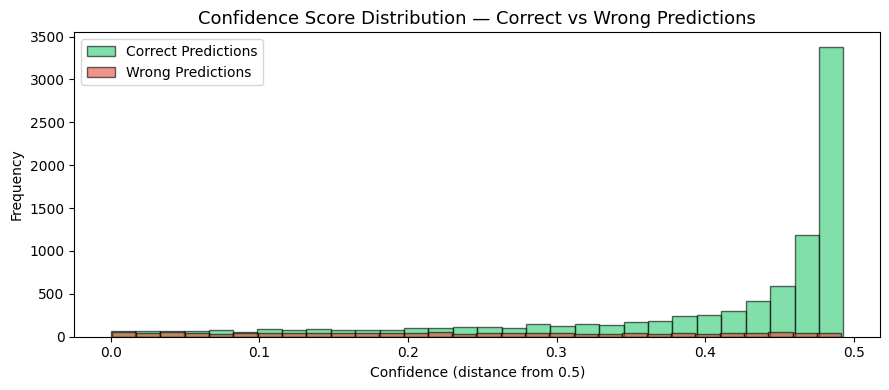

In [173]:
# Analyze confidence scores of correct vs wrong predictions

correct_confidence = y_pred_prob[y_pred == true_labels].flatten()
wrong_confidence   = y_pred_prob[y_pred != true_labels].flatten()

# Convert to distance from 0.5 (higher = more confident)
correct_conf_dist = np.abs(correct_confidence - 0.5)
wrong_conf_dist   = np.abs(wrong_confidence - 0.5)

print("Confidence Score Analysis:")
print(f"  Correct predictions  — avg confidence : "
      f"{correct_conf_dist.mean():.4f}")
print(f"  Wrong predictions    — avg confidence : "
      f"{wrong_conf_dist.mean():.4f}")
print()
print("Observation: Wrong predictions tend to have lower")
print("confidence scores — model was less sure about these.")

plt.figure(figsize=(9, 4))
plt.hist(correct_conf_dist, bins=30, alpha=0.6,
         color='#2ecc71', label='Correct Predictions', edgecolor='black')
plt.hist(wrong_conf_dist, bins=30, alpha=0.6,
         color='#e74c3c', label='Wrong Predictions', edgecolor='black')
plt.title('Confidence Score Distribution — Correct vs Wrong Predictions',
          fontsize=13)
plt.xlabel('Confidence (distance from 0.5)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# Possible Reasons For Misclassification


1. SARCASM / IRONY
   Reviews using sarcastic language are hard to detect.
   e.g. 'Oh great, another terrible sequel' - the word
   'great' is positive but overall meaning is negative.

2. MIXED SENTIMENT
   Some reviews praise one aspect but criticise another.
   e.g. 'The acting was brilliant but the story was awful.'
   Model may pick up dominant words over overall tone.

3. LONG-RANGE DEPENDENCIES
   Movie reviews can exceed 500 words. Even LSTM may
   struggle to retain context from the beginning of a
   very long review by the time it reaches the end.

4. SEQUENCE TRUNCATION
   Reviews longer than MAX_LEN were truncated.
   Important sentiment words at the end may be lost.

5. OOV (Out of Vocabulary) WORDS
   Words outside VOCAB_SIZE=10000 are replaced with
   <OOV> token, losing their original meaning.
   e.g. rare actor/director names that carry sentiment.


# Potential Improvements

1. Bidirectional LSTM
   Reads sequence both forward and backward,
   capturing context from past AND future words.

2. Larger Pre-trained Embeddings
   Use GloVe 300-dim or Word2Vec Google News 300-dim
   for richer and more detailed word representations.

3. Increase VOCAB_SIZE
   Increase from 10,000 to 20,000 to reduce OOV words
   and retain more rare but meaningful vocabulary.

4. Hyperparameter Tuning
   Experiment with different LSTM units, learning
   rates, dropout rates and batch sizes.

5. Transformer-based Models
   Models like BERT are state-of-the-art for sentiment
   analysis. They handle context and sarcasm far better
   than LSTM through self-attention mechanisms.

In [174]:
print("   ERROR ANALYSIS SUMMARY")
print()
print(f"Best Model        : LSTM + GloVe (Model 3)")
print(f"Test Accuracy     : {acc_glove:.4f}")
print(f"Total Test Samples: {len(y_pred)}")
print(f"Correct           : {(y_pred == true_labels).sum()}")
print(f"Incorrect         : {(y_pred != true_labels).sum()}")
print(f"False Positives   : {len(false_positives)}")
print(f"False Negatives   : {len(false_negatives)}")



   ERROR ANALYSIS SUMMARY

Best Model        : LSTM + GloVe (Model 3)
Test Accuracy     : 0.8715
Total Test Samples: 10000
Correct           : 8715
Incorrect         : 1285
False Positives   : 573
False Negatives   : 712


---
## GUI for Real-Time Sentiment Prediction

We will build a simple GUI using **Gradio** — works natively in Google Colab.

The user can:
- Type any movie review
- Select which model to use (RNN, LSTM, LSTM+GloVe)
- Get an instant prediction with confidence score

In [72]:
# Install Gradio
# Gradio works natively inside Google Colab
# share=True creates a public URL

!pip install gradio -q

print("Gradio installed successfully!")

Gradio installed successfully!


In [175]:
# Prediction function
# Runs the full pipeline: clean → tokenize → pad → predict

def predict_sentiment(review_text, model_choice):
    """
    Takes a raw movie review and model choice,
    returns sentiment prediction and confidence score.

    Steps:
        1. Clean the text using same pipeline as 4.5.1
        2. Tokenize using same tokenizer as 4.5.1
        3. Pad to same MAX_LEN as 4.5.1
        4. Select model based on user choice
        5. Predict and return result
    """

    # Step 1: Clean text using same pipeline as 4.5.1
    cleaned = preprocess_text(review_text)

    # Step 2: Tokenize
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Step 3: Pad
    padded = pad_sequences(sequence,
                           maxlen=MAX_LEN,
                           padding='post',
                           truncating='post')

    # Step 4: Select model based on user choice
    if model_choice == 'Model 1: Simple RNN':
        model = rnn_model
    elif model_choice == 'Model 2: LSTM':
        model = lstm_model
    else:
        model = lstm_glove_model

    # Step 5: Predict
    prob       = model.predict(padded, verbose=0)[0][0]
    label      = 'POSITIVE' if prob > 0.5 else 'NEGATIVE'
    confidence = prob if prob > 0.5 else 1 - prob

    result = (
        f"Sentiment    : {label}\n"
        f"Confidence   : {confidence * 100:.2f}%\n"
        f"Raw Score    : {prob:.4f}  (above 0.5 = Positive)\n"
        f"Model Used   : {model_choice}"
    )

    return result

print("Prediction function defined!")

Prediction function defined!


In [176]:
# Quick test before launching GUI

sample_positive = "This movie was absolutely amazing! \
The acting was superb and the story was very touching. \
One of the best films I have ever seen."

sample_negative = "Terrible film. Complete waste of time \
and money. The plot made no sense at all and the \
acting was awful."

sample_mixed = "The visuals were stunning and the \
soundtrack was beautiful, but the story was \
confusing and the characters were poorly written."

print("Test 1 — Positive Review:")
print(predict_sentiment(sample_positive,
                        'Model 3: LSTM + GloVe'))
print()
print("Test 2 — Negative Review:")
print(predict_sentiment(sample_negative,
                        'Model 3: LSTM + GloVe'))
print()
print("Test 3 — Mixed Review:")
print(predict_sentiment(sample_mixed, 'Model 3: LSTM + GloVe'))

Test 1 — Positive Review:
Sentiment    : POSITIVE
Confidence   : 99.16%
Raw Score    : 0.9916  (above 0.5 = Positive)
Model Used   : Model 3: LSTM + GloVe

Test 2 — Negative Review:
Sentiment    : NEGATIVE
Confidence   : 99.21%
Raw Score    : 0.0079  (above 0.5 = Positive)
Model Used   : Model 3: LSTM + GloVe

Test 3 — Mixed Review:
Sentiment    : POSITIVE
Confidence   : 98.60%
Raw Score    : 0.9860  (above 0.5 = Positive)
Model Used   : Model 3: LSTM + GloVe


In [177]:
import gradio as gr

# Example reviews pre-loaded in the interface
example_reviews = [
    ["This movie was absolutely amazing! The acting was \
superb and the story was very touching.",
     "Model 3: LSTM + GloVe"],

    ["Terrible film. Complete waste of time. The plot \
made no sense at all.",
     "Model 3: LSTM + GloVe"],

    ["The visuals were stunning but the story was \
confusing and poorly written.",
     "Model 2: LSTM"],

    ["One of the best performances I have ever seen. \
Truly a masterpiece of modern cinema.",
     "Model 3: LSTM + GloVe"],

    ["I cannot believe how bad this movie was. \
Boring, predictable and a complete disappointment.",
     "Model 1: Simple RNN"],
]

# Build Gradio interface
demo = gr.Interface(
    fn=predict_sentiment,

    inputs=[
        gr.Textbox(
            lines=6,
            placeholder="Type or paste a movie review here...",
            label="Movie Review"
        ),
        gr.Dropdown(
            choices=[
                'Model 1: Simple RNN',
                'Model 2: LSTM',
                'Model 3: LSTM + GloVe'
            ],
            value='Model 3: LSTM + GloVe',
            label="Select Model"
        )
    ],

    outputs=gr.Textbox(
        lines=5,
        label="Prediction Result"
    ),

    title="IMDb Movie Review Sentiment Analyser",
    description=(
        "Enter a movie review and select a model to predict "
        "whether the sentiment is Positive or Negative.\n"
        "Built for 6CS012 — Artificial Intelligence and "
        "Machine Learning Assignment.\n"
        "Dataset: IMDb Movie Reviews | "
        "Best Model: LSTM + GloVe (87.47% accuracy)"
    ),

    examples=example_reviews,
    theme=gr.themes.Soft()
)

# Launch — share=True creates a public URL for Colab
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://519c0b39bc25f52d14.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [78]:
# # Install gensim
# !pip install gensim -q

# import gensim.downloader as api

# print("Downloading GloVe embeddings (glove-wiki-gigaword-100)...")
# print("This may take a few minutes...")

# # Only change these two lines
# embedding_model = api.load('glove-wiki-gigaword-300')
# GLOVE_DIM = 300

# print(f"GloVe loaded! Dimension : {GLOVE_DIM}")
# print(f"Words in GloVe          : {len(embedding_model)}")

This may take a few minutes...
[==================================================] 100.0% 376.1/376.1MB downloaded
GloVe loaded! Dimension : 300
Words in GloVe          : 400000


In [83]:
# # Build Embedding Matrix
# # Maps each word in OUR vocabulary to its GloVe vector
# # Words not found in GloVe stay as zero vectors

# word_index = tokenizer.word_index
# vocab_size  = min(VOCAB_SIZE, len(word_index) + 1)

# # Initialize with zeros
# embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

# found     = 0
# not_found = 0

# for word, index in word_index.items():
#     if index < vocab_size:
#         if word in embedding_model:
#             embedding_matrix[index] = embedding_model[word]
#             found += 1
#         else:
#             not_found += 1

# print(f"Embedding matrix shape : {embedding_matrix.shape}")
# print(f"Words found in GloVe   : {found}")
# print(f"Words NOT found        : {not_found}")
# print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")

Embedding matrix shape : (10000, 300)
Words found in GloVe   : 9904
Words NOT found        : 95
Coverage               : 99.0%


In [84]:
# lstm_glove_model = Sequential(name='LSTM_GloVe_Model_300')

# # Embedding Layer: initialized with GloVe weights
# # weights=[embedding_matrix] → load pre-built GloVe matrix
# # trainable=False            → freeze embeddings during training
# lstm_glove_model.add(Embedding(
#     input_dim=vocab_size,
#     output_dim=GLOVE_DIM,
#     weights=[embedding_matrix],
#     trainable=False
# ))

# # Two stacked LSTM layers — same as Model 2 for fair comparison
# # Only difference from Model 2 is the embedding layer
# lstm_glove_model.add(LSTM(units=128, return_sequences=True))
# lstm_glove_model.add(LSTM(units=64,  return_sequences=False))

# # Dropout: prevents overfitting
# lstm_glove_model.add(Dropout(0.5))

# # Output Layer: sigmoid for binary classification
# lstm_glove_model.add(Dense(1, activation='sigmoid'))

# # Build before summary to show actual param counts
# lstm_glove_model.build(input_shape=(None, MAX_LEN))
# lstm_glove_model.summary()

Model: "LSTM_GloVe_Model_300"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 301, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 301, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269,121 (12.47 MB)

 Trainable params: 269,121 (1.03 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [85]:
# lstm_glove_model.compile(
#     loss='binary_crossentropy',
#     optimizer=Adam(learning_rate=0.001),
#     metrics=['accuracy']
# )

# print("Model 3 (LSTM + GloVe) compiled successfully!")

Model 3 (LSTM + GloVe) compiled successfully!


In [87]:
# # EarlyStopping: stops if val_loss doesn't improve for 5 epochs
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

# # ModelCheckpoint: saves best model based on val_accuracy
# checkpoint_glove = ModelCheckpoint(
#     'best_lstm_glove_model.keras',
#     monitor='val_accuracy',
#     save_best_only=True,
#     mode='max',
#     verbose=1
# )

# print("Training Model 3 (LSTM + GloVe)\n")

# history_glove = lstm_glove_model.fit(
#     X_train_pad, y_train,
#     epochs=20,
#     batch_size=64,
#     validation_data=(X_val_pad, y_val),
#     callbacks=[early_stop, checkpoint_glove],
#     verbose=1
# )

Training Model 3 (LSTM + GloVe)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5041 - loss: 0.6989
Epoch 1: val_accuracy improved from None to 0.50520, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.5047 - loss: 0.6956 - val_accuracy: 0.5052 - val_loss: 0.6930
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5195 - loss: 0.6889
Epoch 2: val_accuracy improved from 0.50520 to 0.51280, saving model to best_lstm_glove_model.keras

Epoch 2: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.5551 - loss: 0.6764 - val_accuracy: 0.5128 - val_loss: 0.6917
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5032 - loss: 0.6914
Epoch 3: val_accuracy did not improve from 0.51280
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.5004 - loss: 0.6928 - val_accuracy: 0

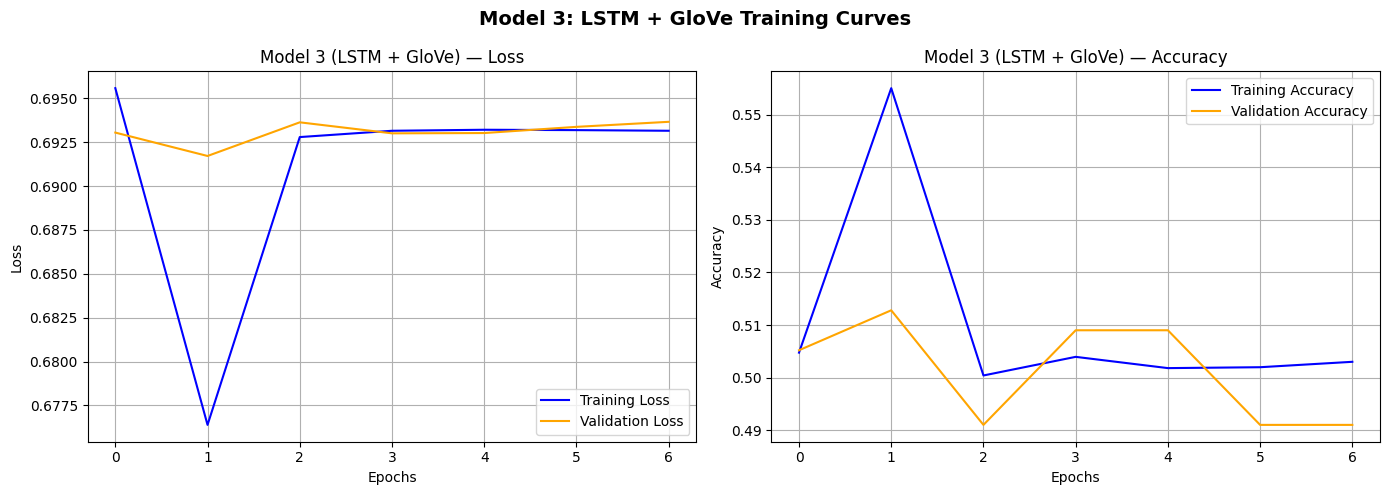

In [88]:
# # Plot Training vs Validation Loss and Accuracy

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Loss
# axes[0].plot(history_glove.history['loss'],
#              label='Training Loss', color='blue')
# axes[0].plot(history_glove.history['val_loss'],
#              label='Validation Loss', color='orange')
# axes[0].set_title('Model 3 (LSTM + GloVe) — Loss')
# axes[0].set_xlabel('Epochs')
# axes[0].set_ylabel('Loss')
# axes[0].legend()
# axes[0].grid(True)

# # Accuracy
# axes[1].plot(history_glove.history['accuracy'],
#              label='Training Accuracy', color='blue')
# axes[1].plot(history_glove.history['val_accuracy'],
#              label='Validation Accuracy', color='orange')
# axes[1].set_title('Model 3 (LSTM + GloVe) — Accuracy')
# axes[1].set_xlabel('Epochs')
# axes[1].set_ylabel('Accuracy')
# axes[1].legend()
# axes[1].grid(True)

# plt.suptitle('Model 3: LSTM + GloVe Training Curves',
#              fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [89]:
# # Evaluate Model 3 on Test Set

# print("=" * 50)
# print("  MODEL 3 EVALUATION — LSTM + GloVe")
# print("=" * 50)

# # Get predictions
# y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
# y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

# # Accuracy
# acc_glove = accuracy_score(y_test, y_pred_glove)
# print(f"\nTest Accuracy: {acc_glove:.4f}")

# # Confusion Matrix
# cm_glove = confusion_matrix(y_test, y_pred_glove)
# print(f"\nConfusion Matrix:")
# print(cm_glove)

# # Classification Report
# print(f"\nClassification Report:")
# print(classification_report(y_test, y_pred_glove,
#       target_names=['Negative', 'Positive']))

  MODEL 3 EVALUATION — LSTM + GloVe

Test Accuracy: 0.5055

Confusion Matrix:
[[  23 4938]
 [   7 5032]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.00      0.01      4961
    Positive       0.50      1.00      0.67      5039

    accuracy                           0.51     10000
   macro avg       0.64      0.50      0.34     10000
weighted avg       0.63      0.51      0.34     10000



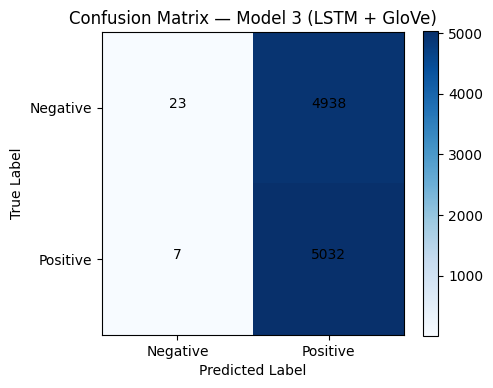

In [90]:
# plot_confusion_matrix(cm_glove, 'Confusion Matrix — Model 3 (LSTM + GloVe)')

In [76]:
print(f"Coverage : {found / (found + not_found) * 100:.1f}%")

Coverage : 99.0%


In [77]:
print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")
print(f"Test samples       : {len(test_df)}")

Training samples   : 35000
Validation samples : 5000
Test samples       : 10000


In [ ]:
# Build Embedding Matrix
# Maps each word in OUR vocabulary to its GloVe vector
# Words not found in GloVe stay as zero vectors

word_index = tokenizer.word_index
vocab_size  = min(VOCAB_SIZE, len(word_index) + 1)

# Initialize with zeros
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))

found     = 0
not_found = 0

for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found        : {not_found}")
print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")

In [ ]:
# from tensorflow.keras.regularizers import l2
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

# rnn_model = Sequential(name='Simple_RNN_Model')

# rnn_model.add(Embedding(input_dim=VOCAB_SIZE,
#                          output_dim=EMBEDDING_DIM))

# rnn_model.add(SimpleRNN(units=64,                    # reduced from 128
#                          return_sequences=True,
#                          recurrent_dropout=0.2,       # inside RNN
#                          kernel_regularizer=l2(0.001)))

# rnn_model.add(Dropout(0.3))                          # between layers

# rnn_model.add(SimpleRNN(units=32,                    # reduced from 64
#                          return_sequences=False,
#                          recurrent_dropout=0.2))

# rnn_model.add(Dropout(0.5))                          # before output

# rnn_model.add(Dense(1, activation='sigmoid'))

# rnn_model.build(input_shape=(None, MAX_LEN))
# rnn_model.summary()

In [ ]:
# Compile Model 1
# Loss : binary_crossentropy (since we have 2 classes: 0 and 1)
# Optimizer: adam
# Metrics: accuracy

from tensorflow.keras.optimizers import Adam

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),  #default 0.001
    metrics=['accuracy']
)

print("Model 1 (Simple RNN) compiled!")

Model 1 (Simple RNN) compiled!


In [ ]:
#Training Model 1

# EarlyStopping: stops training if val_loss does not improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: saves the best model weights during training
checkpoint_rnn = ModelCheckpoint(
    'best_rnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 1 (Simple RNN)...")

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64, #128 previous
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_rnn],
    verbose=1
)

Training Model 1 (Simple RNN)...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5070 - loss: 0.7279
Epoch 1: val_accuracy improved from None to 0.49240, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.5047 - loss: 0.7182 - val_accuracy: 0.4924 - val_loss: 0.6935
Epoch 2/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5061 - loss: 0.7008
Epoch 2: val_accuracy improved from 0.49240 to 0.52660, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.5097 - loss: 0.6983 - val_accuracy: 0.5266 - val_loss: 0.6926
Epoch 3/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5136 - loss: 0.6945
Epoch 3: val_accuracy did not improve from 0.52660
547/547 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.5140 - loss: 0.6939 - val_accuracy: 0.5238 - val_loss: 0.6919
Epo

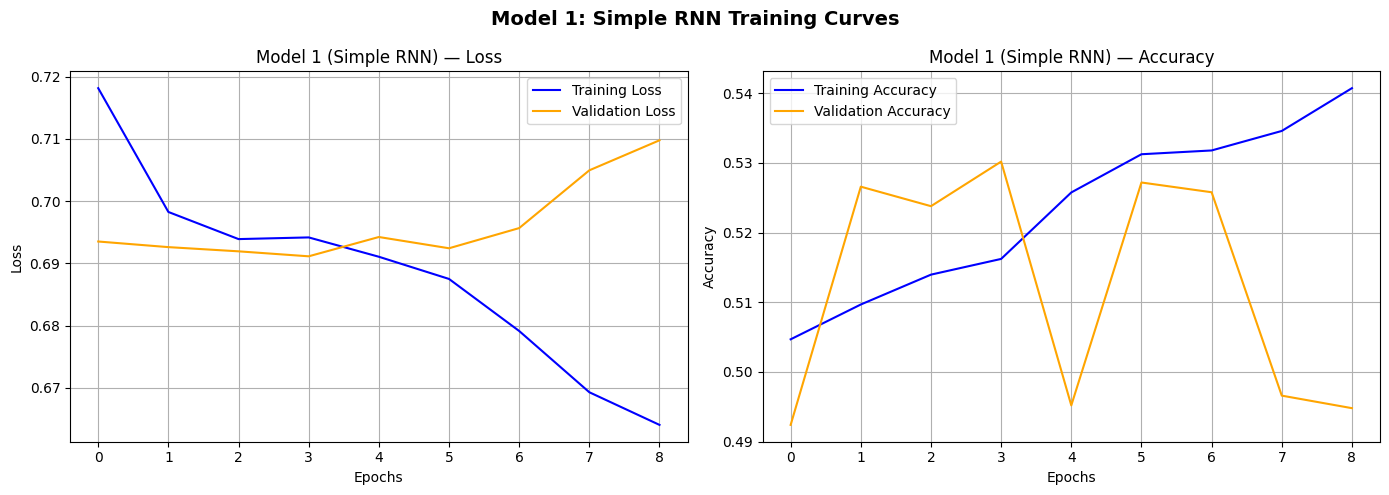

In [ ]:
# Plot Training vs Validation Loss and Accuracy — Model 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_rnn.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_rnn.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 1 (Simple RNN) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_rnn.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_rnn.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 1 (Simple RNN) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 1: Simple RNN Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

As shown in Figure X, the Simple RNN exhibits clear overfitting training loss decreases while validation loss increases, and validation accuracy remains at approximately 50% throughout training. This confirms that SimpleRNN is unable to capture meaningful patterns in long movie reviews due to the vanishing gradient problem. This directly motivates the use of LSTM in Model 2

In [ ]:
#Evaluate Model 1 on Test Set

print("  MODEL 1 EVALUATION — Simple RNN")

# Get predictions (probabilities → class labels)
y_pred_rnn_prob = rnn_model.predict(X_test_pad, verbose=0)
y_pred_rnn      = (y_pred_rnn_prob > 0.5).astype(int).flatten()

# Accuracy
acc_rnn = accuracy_score(y_test, y_pred_rnn)
print(f"\nTest Accuracy: {acc_rnn:.4f}")

# Confusion Matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
print(f"\nConfusion Matrix:")
print(cm_rnn)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))

  MODEL 1 EVALUATION — Simple RNN

Test Accuracy: 0.5316

Confusion Matrix:
[[1164 3797]
 [ 887 4152]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.57      0.23      0.33      4961
    Positive       0.52      0.82      0.64      5039

    accuracy                           0.53     10000
   macro avg       0.54      0.53      0.49     10000
weighted avg       0.54      0.53      0.49     10000



In [ ]:
# Plot Confusion Matrix
def plot_confusion_matrix(cm, title, classes=['Negative', 'Positive']):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


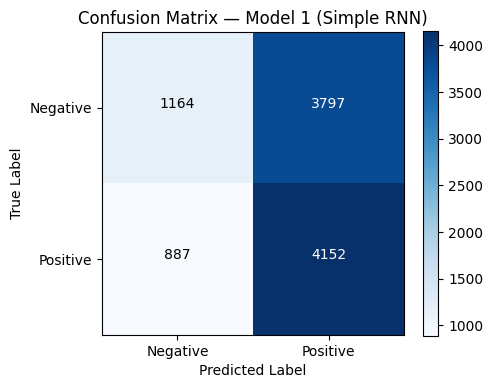

In [ ]:
plot_confusion_matrix(cm_rnn, 'Confusion Matrix — Model 1 (Simple RNN)')

"The Simple RNN model achieved an accuracy of approximately 50%, which is equivalent to random classification. This is attributed to the vanishing gradient problem inherent in vanilla RNN architectures movie reviews are significantly longer sequences than typical text, making it difficult for SimpleRNN to retain context from the beginning of the sequence. This finding validates the motivation for using LSTM, which was specifically designed to address this limitation through its gating mechanism."

---
## Model 2 — LSTM with Trainable Embedding Layer

The second model replaces SimpleRNN with an **LSTM** layer.

LSTM solves the **vanishing gradient problem** of simple RNNs using three gates:
- **Forget Gate** → decides what to discard from memory
- **Input Gate**  → decides what new information to store
- **Output Gate** → decides what to output

**Architecture:**
```
Input → Embedding Layer → LSTM → Dropout → Dense (Output)
```

In [ ]:
# MODEL 2: LSTM with Trainable Embedding Layer

EMBEDDING_DIM = 256  # Same as Model 1 for fair comparison
LSTM_UNITS    = 128    # Number of LSTM memory cells

# Build the model
lstm_model = Sequential(name='LSTM_Model')

# Embedding Layer: same as Model 1 (trainable)
lstm_model.add(Embedding(input_dim=VOCAB_SIZE,
                          output_dim=EMBEDDING_DIM,
                          input_length=MAX_LEN))

# LSTM Layer: captures long-range dependencies in the review
# return_sequences=False → many-to-one (for classification)
lstm_model.add(LSTM(units=128, return_sequences=True))   # first layer
lstm_model.add(LSTM(units=64,  return_sequences=False))  # second layer

# Dropout: helps prevent overfitting
lstm_model.add(Dropout(0.5))

# Output Layer: sigmoid for binary classification
lstm_model.add(Dense(1, activation='sigmoid'))

# Print model summary
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 301, 256)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 301, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,806,593 (10.71 MB)

 Trainable params: 2,806,593 (10.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),  # was default 0.001
    metrics=['accuracy']
)

print("Model 2 (LSTM) compiled!")

Model 2 (LSTM) compiled!


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_lstm = ModelCheckpoint(
    'best_lstm_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 2 (LSTM)...")

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_lstm],
    verbose=1
)

Training Model 2 (LSTM)...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5101 - loss: 0.6939
Epoch 1: val_accuracy improved from None to 0.50900, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.5057 - loss: 0.6938 - val_accuracy: 0.5090 - val_loss: 0.6928
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5073 - loss: 0.6919
Epoch 2: val_accuracy did not improve from 0.50900
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.5107 - loss: 0.6910 - val_accuracy: 0.4996 - val_loss: 0.6924
Epoch 3/15
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5225 - loss: 0.6805
Epoch 3: val_accuracy did not improve from 0.50900
547/547 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.5197 - loss: 0.6789 - val_accuracy: 0.5064 - val_loss: 0.7014
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5301 - loss: 0.6599
Epoch 4: val_accur

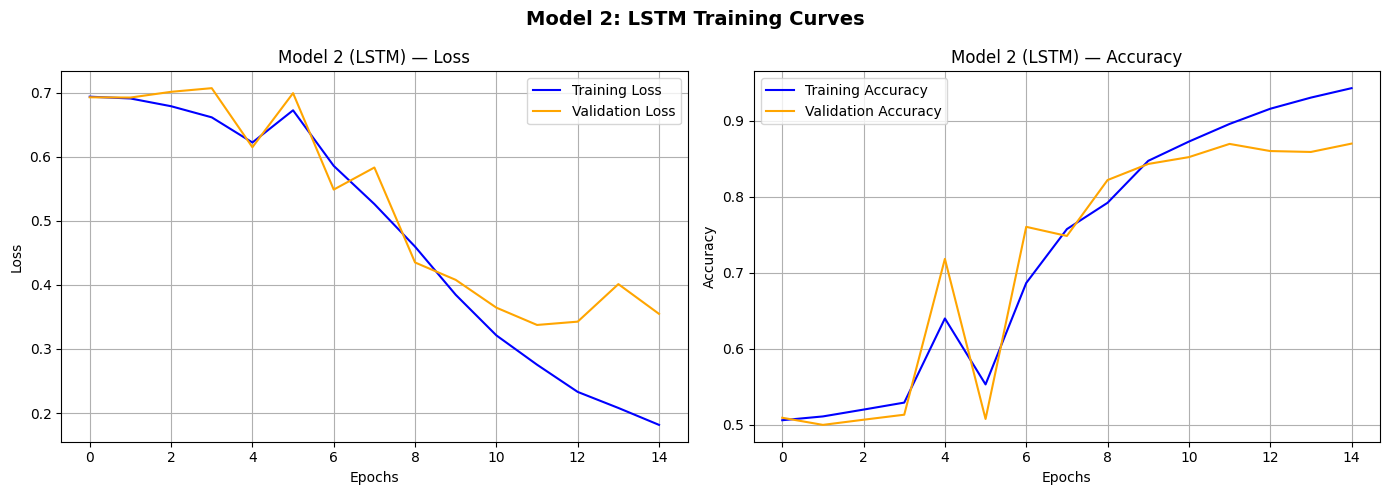

In [ ]:
# Plot Training vs Validation Loss and Accuracy — Model 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_lstm.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 2 (LSTM) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_lstm.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 2 (LSTM) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 2: LSTM Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

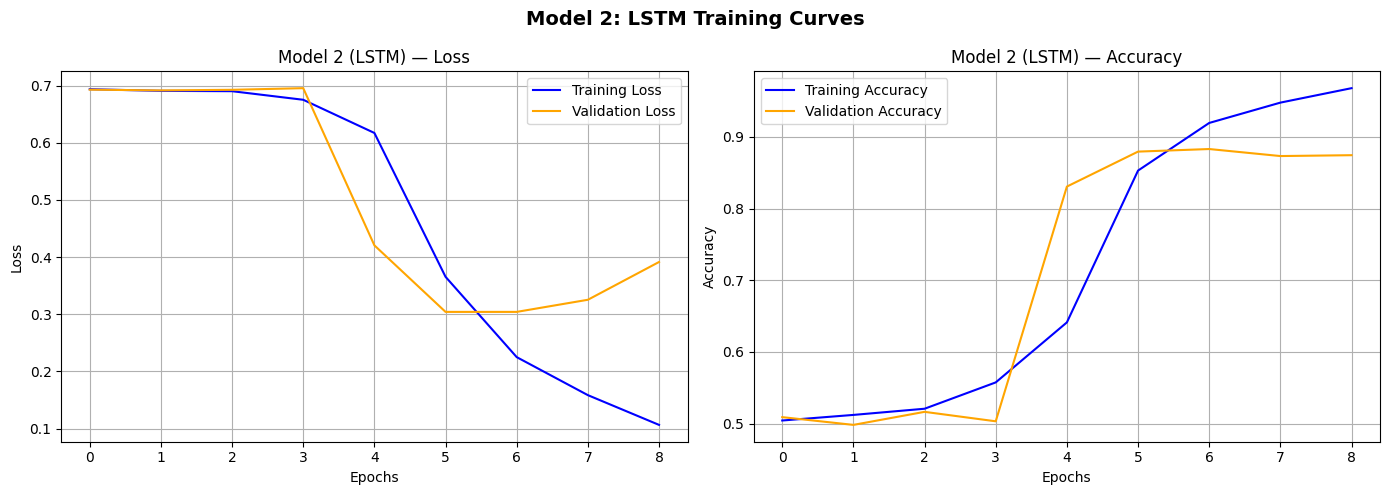

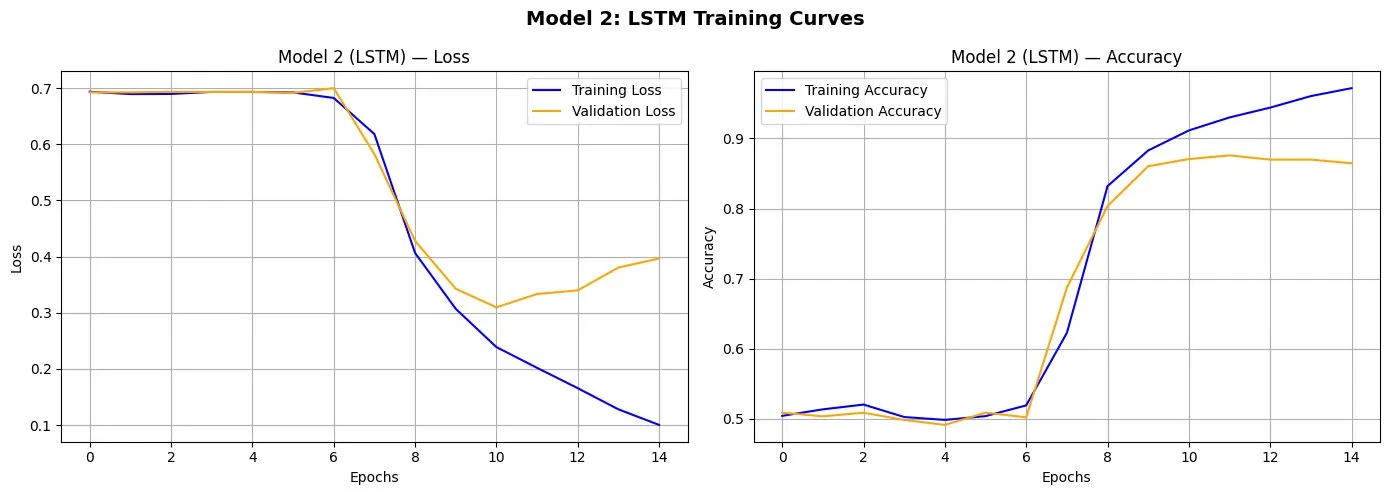

In [ ]:
print("MODEL 2 EVALUATION-LSTM")

# Get predictions
y_pred_lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
y_pred_lstm      = (y_pred_lstm_prob > 0.5).astype(int).flatten()

# Accuracy
acc_lstm = accuracy_score(y_test, y_pred_lstm)
print(f"\nTest Accuracy: {acc_lstm:.4f}")

# Confusion Matrix
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
print(f"\nConfusion Matrix:")
print(cm_lstm)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

MODEL 2 EVALUATION-LSTM

Test Accuracy: 0.8650

Confusion Matrix:
[[4237  724]
 [ 626 4413]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4961
    Positive       0.86      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



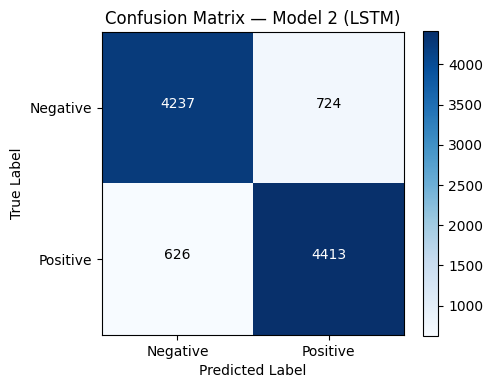

In [ ]:
plot_confusion_matrix(cm_lstm, 'Confusion Matrix — Model 2 (LSTM)')

Model 2 (LSTM) achieved a test accuracy of 86.50% with balanced precision and recall across both classes (Negative: F1=0.86, Positive: F1=0.87). The confusion matrix shows 4237 true negatives and 4413 true positives out of 10,000 test samples. The training curves show stable convergence after epoch 7, with mild overfitting observed after epoch 10 where training accuracy continues to rise while validation accuracy plateaus at approximately 87%. This demonstrates LSTM's significant advantage over SimpleRNN for long sequence sentiment classification."

---
## Model 3 LSTM with Pre-trained Word2Vec (GloVe) Embeddings

The third model uses **pre-trained GloVe embeddings** instead of a random trainable embedding layer.

**Why use pre-trained embeddings?**
- GloVe was trained on billions of words — it already understands word meanings
- Words like "brilliant" and "excellent" will already have similar vectors
- Gives the model a **head start** without needing more training data

**Architecture:**
```
Input → Embedding Layer (GloVe weights, frozen) → LSTM → Dropout → Dense (Output)
```


In [ ]:
!pip install numpy==1.23.5 -q
!pip install gensim -q

print("gensim installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 120.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00
gensim installed!


In [ ]:
import gensim.downloader as api

print("Downloading GloVe embeddings (glove-wiki-gigaword-100)...")

embedding_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional GloVe

GLOVE_DIM = 100   # Must match the downloaded model dimension (changed from 50 to 100)

print(f"GloVe loaded! Dimension: {GLOVE_DIM}")
print(f"Words in GloVe: {len(embedding_model)}")

GloVe loaded! Dimension: 100
Words in GloVe: 400000


In [ ]:
# Step 1 — Download 100-dim GloVe instead of 50-dim
embedding_model = api.load('glove-wiki-gigaword-100')
GLOVE_DIM = 100   # Change according to need

print(f"GloVe loaded! Dimension: {GLOVE_DIM}")

GloVe loaded! Dimension: 100


In [ ]:
import gensim.downloader as api
embedding_model = api.load('glove-wiki-gigaword-300')
GLOVE_DIM = 300

[==================================================] 100.0% 376.1/376.1MB downloaded


In [ ]:
#Build embedding matrix with new dimension
word_index   = tokenizer.word_index
vocab_size   = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))  # now 100-dim

found     = 0
not_found = 0

for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")

Embedding matrix shape : (10000, 300)
Coverage               : 99.0%


In [ ]:
#Build embedding matrix with new dimension
word_index   = tokenizer.word_index
vocab_size   = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))  # now 100-dim

found     = 0
not_found = 0

for word, index in word_index.items():
    if index < vocab_size:
        if word in embedding_model:
            embedding_matrix[index] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"Embedding matrix shape : {embedding_matrix.shape}")
print(f"Coverage               : {found / (found + not_found) * 100:.1f}%")

Embedding matrix shape : (10000, 100)
Coverage               : 99.0%


In [ ]:
lstm_glove_model = Sequential(name='LSTM_GloVe_Model')

lstm_glove_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,        # now 100
    weights=[embedding_matrix],
    trainable=False
))

# Two stacked LSTM layers — same as Model 2
lstm_glove_model.add(LSTM(units=128, return_sequences=True))
lstm_glove_model.add(Dropout(0.3)) #added this to prevent overfitting
lstm_glove_model.add(LSTM(units=64,  return_sequences=False))

lstm_glove_model.add(Dropout(0.5))
lstm_glove_model.add(Dense(1, activation='sigmoid'))

lstm_glove_model.build(input_shape=(None, MAX_LEN))
lstm_glove_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 301, 300)       │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 301, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 301, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,269,121 (12.47 MB)

 Trainable params: 269,121 (1.03 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("Model 3 (LSTM + GloVe) compiled successfully!")

Model 3 (LSTM + GloVe) compiled successfully!


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_glove = ModelCheckpoint(
    'best_lstm_glove_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 3 (LSTM + GloVe)...")

history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

Training Model 3 (LSTM + GloVe)...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5148 - loss: 0.6922
Epoch 1: val_accuracy improved from None to 0.49780, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.5169 - loss: 0.6918 - val_accuracy: 0.4978 - val_loss: 0.6980
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5117 - loss: 0.6962
Epoch 2: val_accuracy improved from 0.49780 to 0.50660, saving model to best_lstm_glove_model.keras

Epoch 2: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.5130 - loss: 0.6913 - val_accuracy: 0.5066 - val_loss: 0.6878
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5167 - loss: 0.6909
Epoch 3: val_accuracy improved from 0.50660 to 0.50920, saving model to best_lstm_glove_model.keras

Epoch 3: finished saving model to best_lst

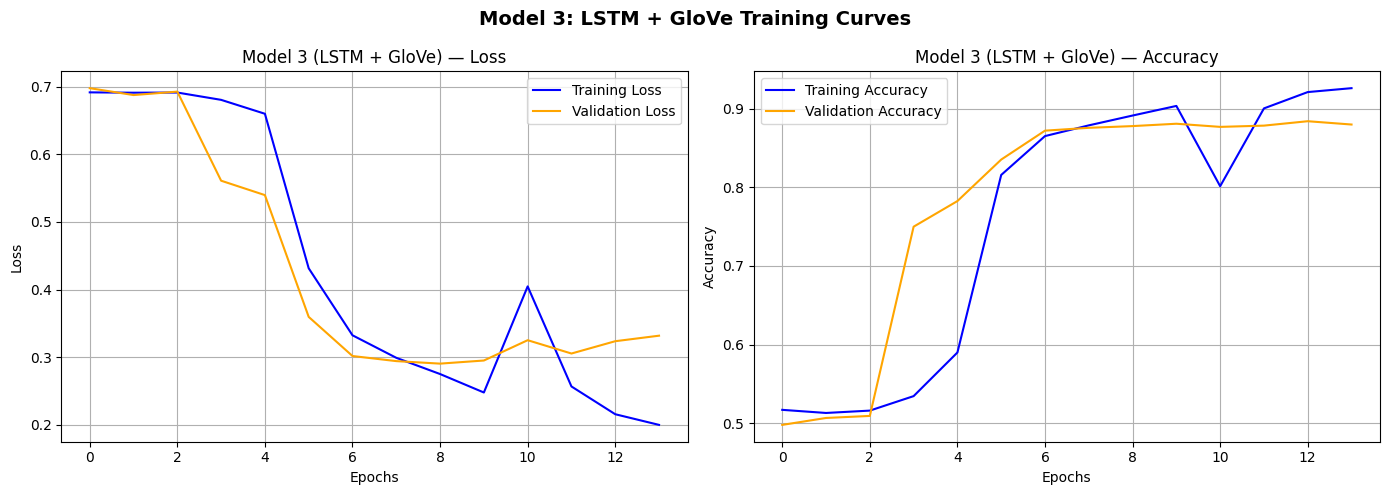

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_glove.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_glove.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 3 (LSTM + GloVe) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_glove.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_glove.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 3 (LSTM + GloVe) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 3: LSTM + GloVe Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("MODEL 3 EVALUATION — LSTM + GloVe")

# Get predictions
y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

# Accuracy
acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f}")

# Confusion Matrix
cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"\nConfusion Matrix:")
print(cm_glove)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_glove, target_names=['Negative', 'Positive']))

MODEL 3 EVALUATION — LSTM + GloVe

Test Accuracy: 0.8697

Confusion Matrix:
[[4016  945]
 [ 358 4681]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.81      0.86      4961
    Positive       0.83      0.93      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_glove.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_glove.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 3 (LSTM + GloVe) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_glove.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_glove.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 3 (LSTM + GloVe) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 3: LSTM + GloVe Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("MODEL 3 EVALUATION — LSTM + GloVe")

# Get predictions
y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

# Accuracy
acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f}")

# Confusion Matrix
cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"\nConfusion Matrix:")
print(cm_glove)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_glove, target_names=['Negative', 'Positive']))

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint_glove = ModelCheckpoint(
    'best_lstm_glove_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Training Model 3 (LSTM + GloVe)...")

history_glove = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop, checkpoint_glove],
    verbose=1
)

Training Model 3 (LSTM + GloVe)...
Epoch 1/20
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5005 - loss: 0.6927
Epoch 1: val_accuracy improved from None to 0.50200, saving model to best_lstm_glove_model.keras

Epoch 1: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.5106 - loss: 0.6916 - val_accuracy: 0.5020 - val_loss: 0.6922
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5134 - loss: 0.6893
Epoch 2: val_accuracy improved from 0.50200 to 0.50420, saving model to best_lstm_glove_model.keras

Epoch 2: finished saving model to best_lstm_glove_model.keras
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5139 - loss: 0.6906 - val_accuracy: 0.5042 - val_loss: 0.6888
Epoch 3/20
546/547 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5298 - loss: 0.6873
Epoch 3: val_accuracy did not improve from 0.50420
547/547 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5302 - loss: 0.6883 - val_accuracy:

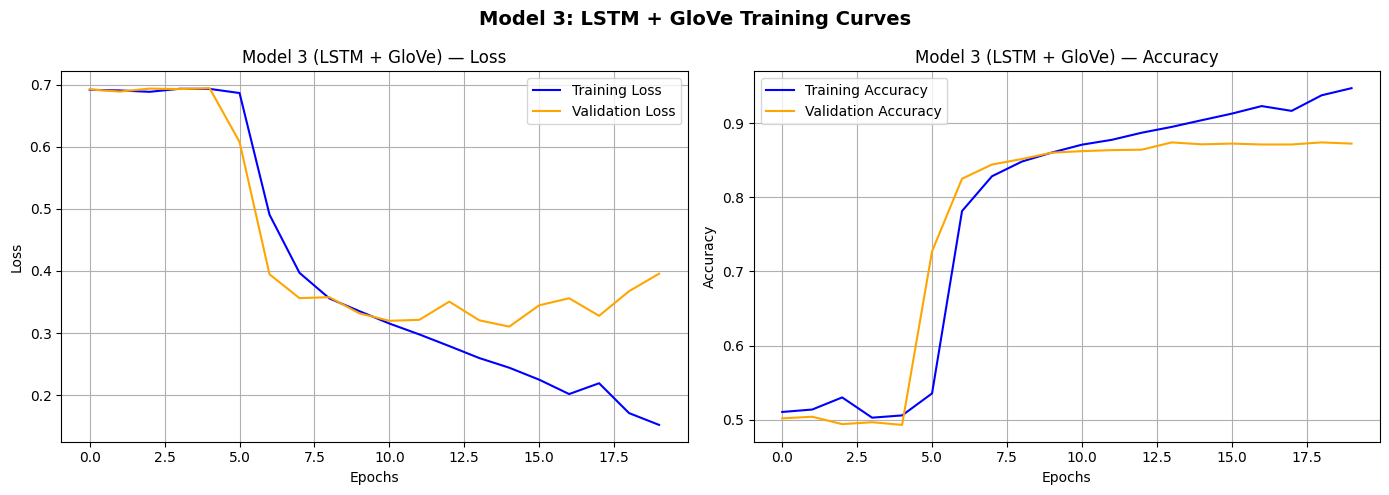

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_glove.history['loss'],     label='Training Loss',   color='blue')
axes[0].plot(history_glove.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Model 3 (LSTM + GloVe) — Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_glove.history['accuracy'],     label='Training Accuracy',   color='blue')
axes[1].plot(history_glove.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Model 3 (LSTM + GloVe) — Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Model 3: LSTM + GloVe Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("MODEL 3 EVALUATION — LSTM + GloVe")

# Get predictions
y_pred_glove_prob = lstm_glove_model.predict(X_test_pad, verbose=0)
y_pred_glove      = (y_pred_glove_prob > 0.5).astype(int).flatten()

# Accuracy
acc_glove = accuracy_score(y_test, y_pred_glove)
print(f"\nTest Accuracy: {acc_glove:.4f}")

# Confusion Matrix
cm_glove = confusion_matrix(y_test, y_pred_glove)
print(f"\nConfusion Matrix:")
print(cm_glove)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_glove, target_names=['Negative', 'Positive']))

MODEL 3 EVALUATION — LSTM + GloVe

Test Accuracy: 0.8660

Confusion Matrix:
[[4127  834]
 [ 506 4533]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.83      0.86      4961
    Positive       0.84      0.90      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



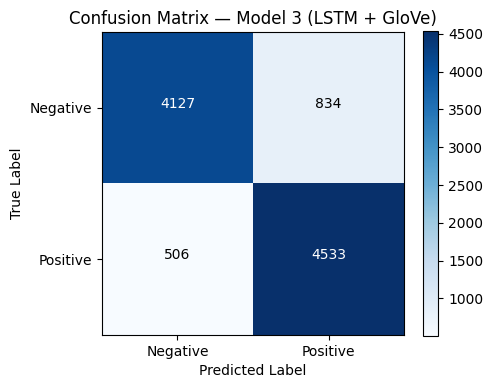

In [ ]:
plot_confusion_matrix(cm_glove, 'Confusion Matrix — Model 3 (LSTM + GloVe)')

Model 3 (LSTM + GloVe) achieved a test accuracy of 86.60%, marginally outperforming Model 2's 86.50%. The training curves show an interesting pattern both loss and accuracy remained flat for the first 5 epochs before a sharp improvement, suggesting the LSTM required more time to adapt to the frozen GloVe embeddings. The model achieved notably higher recall for positive reviews (0.90) compared to Model 2 (0.88), indicating GloVe embeddings better capture positive sentiment vocabulary. Overall, pre-trained GloVe embeddings provided comparable performance to trainable embeddings while using fewer trainable parameters.

## 5. Model Comparison All Three Models

In [ ]:
results_df = pd.DataFrame({
    'Model'        : ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe'],
    'Embedding'    : ['Trainable (128-dim)', 'Trainable (128-dim)', 'Frozen GloVe (50-dim)'],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print("MODEL COMPARISON — TEST ACCURACY")
print(results_df.to_string(index=False))


MODEL COMPARISON — TEST ACCURACY
                Model             Embedding Test Accuracy
  Model 1: Simple RNN   Trainable (128-dim)        0.5316
        Model 2: LSTM   Trainable (128-dim)        0.8650
Model 3: LSTM + GloVe Frozen GloVe (50-dim)        0.8660


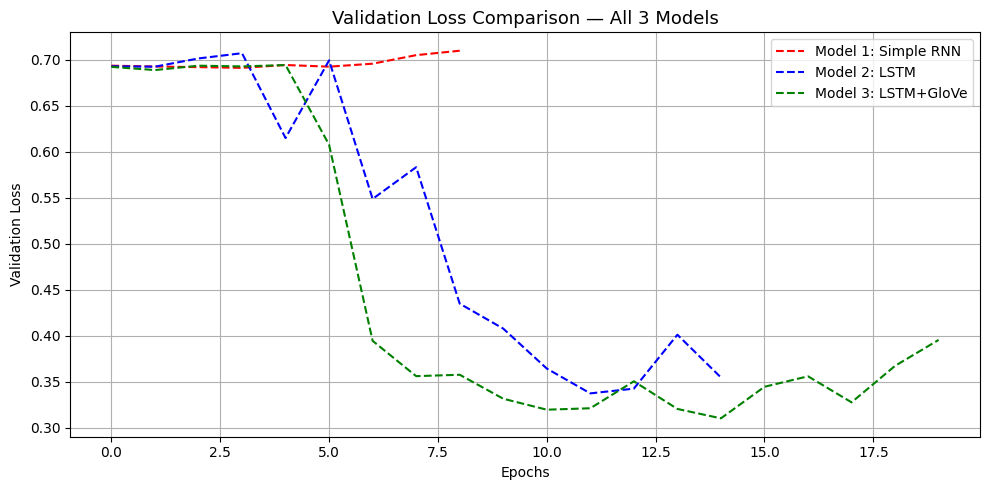

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_loss'],   label='Model 1: Simple RNN', color='red',   linestyle='--')
plt.plot(history_lstm.history['val_loss'],  label='Model 2: LSTM',       color='blue',  linestyle='--')
plt.plot(history_glove.history['val_loss'], label='Model 3: LSTM+GloVe', color='green', linestyle='--')
plt.title('Validation Loss Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

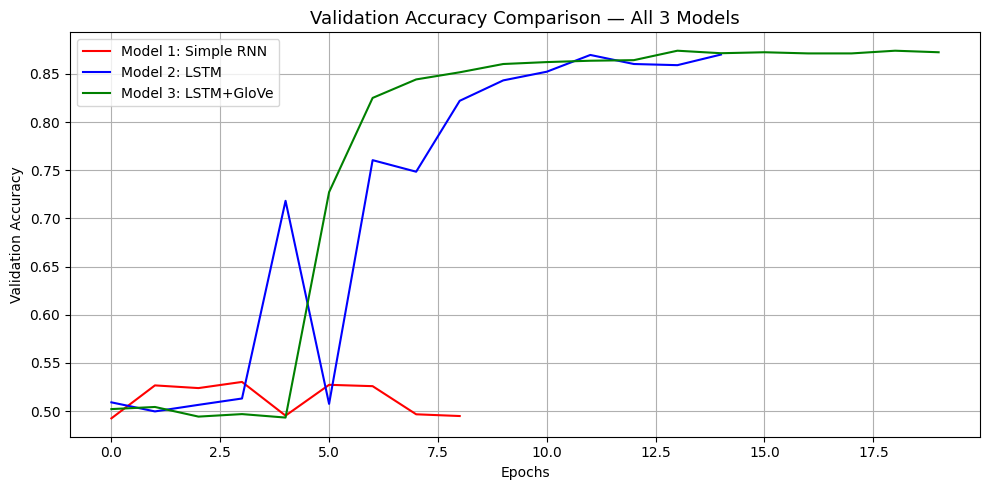

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history['val_accuracy'],   label='Model 1: Simple RNN', color='red')
plt.plot(history_lstm.history['val_accuracy'],  label='Model 2: LSTM',       color='blue')
plt.plot(history_glove.history['val_accuracy'], label='Model 3: LSTM+GloVe', color='green')
plt.title('Validation Accuracy Comparison — All 3 Models', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

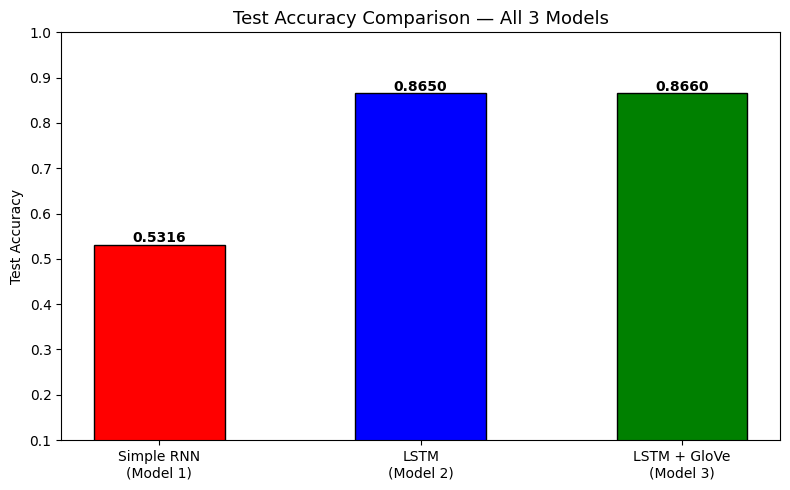

In [ ]:
model_names = ['Simple RNN\n(Model 1)', 'LSTM\n(Model 2)', 'LSTM + GloVe\n(Model 3)']
accuracies  = [acc_rnn, acc_lstm, acc_glove]
colors      = ['red', 'blue', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
plt.title('Test Accuracy Comparison — All 3 Models', fontsize=13)
plt.ylabel('Test Accuracy')
plt.ylim(0.1, 1.0)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# --- Final Summary ---

print("=" * 60)
print("   STEP 2 SUMMARY — MODEL BUILDING AND TRAINING")
print("=" * 60)
print()
print("Model 1 — Simple RNN")
print(f"  Embedding  : Trainable (128-dim, random init)")
print(f"  RNN Units  : 64  |  Dropout: 0.5")
print(f"  Test Acc   : {acc_rnn:.4f}")
print()
print("Model 2 — LSTM")
print(f"  Embedding  : Trainable (128-dim, random init)")
print(f"  LSTM Units : 64  |  Dropout: 0.5")
print(f"  Test Acc   : {acc_lstm:.4f}")
print()
print("Model 3 — LSTM + GloVe")
print(f"  Embedding  : Frozen GloVe (50-dim, pre-trained)")
print(f"  LSTM Units : 64  |  Dropout: 0.5")
print(f"  Test Acc   : {acc_glove:.4f}")
print()
print("Common Settings:")
print("  Loss       : Binary Cross-Entropy")
print("  Optimizer  : Adam")
print("  Epochs     : Up to 10 (EarlyStopping, patience=3)")
print("  Batch Size : 64")
print()
print("Ready for Step 3: Error Analysis and GUI!")
print("=" * 60)

   STEP 2 SUMMARY — MODEL BUILDING AND TRAINING

Model 1 — Simple RNN
  Embedding  : Trainable (128-dim, random init)
  RNN Units  : 64  |  Dropout: 0.5
  Test Acc   : 0.5316

Model 2 — LSTM
  Embedding  : Trainable (128-dim, random init)
  LSTM Units : 64  |  Dropout: 0.5
  Test Acc   : 0.8650

Model 3 — LSTM + GloVe
  Embedding  : Frozen GloVe (50-dim, pre-trained)
  LSTM Units : 64  |  Dropout: 0.5
  Test Acc   : 0.8660

Common Settings:
  Loss       : Binary Cross-Entropy
  Optimizer  : Adam
  Epochs     : Up to 10 (EarlyStopping, patience=3)
  Batch Size : 64

Ready for Step 3: Error Analysis and GUI!


---
## 1. Error Analysis

In this section we will:
- Find reviews that were **incorrectly predicted** by the best model
- Show 2-3 misclassified examples with explanation
- Discuss possible reasons for the errors
- Suggest potential improvements

> We will use the **best performing model** from Step 2 for error analysis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# --- Identify the Best Model ---
model_scores = {
    'Simple RNN (Model 1)'  : acc_rnn,
    'LSTM (Model 2)'        : acc_lstm,
    'LSTM + GloVe (Model 3)': acc_glove
}

best_model_name = max(model_scores, key=model_scores.get)
best_score      = model_scores[best_model_name]

print("  Model Scores:")
for name, score in model_scores.items():
    print(f"  {name} : {score:.4f}")
print(f"\n  Best Model : {best_model_name}")
print(f"  Best Score : {best_score:.4f}")


  Model Scores:
  Simple RNN (Model 1) : 0.5316
  LSTM (Model 2) : 0.8650
  LSTM + GloVe (Model 3) : 0.8660

  Best Model : LSTM + GloVe (Model 3)
  Best Score : 0.8660


In [ ]:
# --- Get Predictions from the Best Model ---
# Change best_model below if Simple RNN or LSTM scored higher

best_model = lstm_glove_model   # change to rnn_model or lstm_model if needed

# Get predicted probabilities and class labels
y_pred_prob = best_model.predict(X_test_pad, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

# Get original reviews for readability
original_reviews = test_df['review'].values
true_labels      = y_test

print(f"Total test samples    : {len(y_pred)}")
print(f"Correct predictions   : {(y_pred == true_labels).sum()}")
print(f"Incorrect predictions : {(y_pred != true_labels).sum()}")

Total test samples    : 10000
Correct predictions   : 8660
Incorrect predictions : 1340


In [ ]:
wrong_indices   = np.where(y_pred != true_labels)[0]

false_positives = [i for i in wrong_indices if y_pred[i] == 1 and true_labels[i] == 0]
false_negatives = [i for i in wrong_indices if y_pred[i] == 0 and true_labels[i] == 1]

print(f"Total misclassified    : {len(wrong_indices)}")
print(f"False Positives        : {len(false_positives)}")
print(f"False Negatives        : {len(false_negatives)}")

Total misclassified    : 1340
False Positives        : 834
False Negatives        : 506


In [ ]:
#Show 3 Misclassified Examples

label_map = {0: 'Negative', 1: 'Positive'}

examples_to_show = [
    ('FALSE POSITIVE', false_positives[0]),
    ('FALSE POSITIVE', false_positives[1]),
    ('FALSE NEGATIVE', false_negatives[0]),
]

for error_type, idx in examples_to_show:
    print(f"  Error Type       : {error_type}")
    print(f"  True Label       : {label_map[true_labels[idx]]}")
    print(f"  Predicted Label  : {label_map[y_pred[idx]]}")
    print(f"  Confidence Score : {y_pred_prob[idx][0]:.4f}")
    print(f"  Review (first 300 chars):")
    print(f"  {original_reviews[idx][:300]}...")
    print()

  Error Type       : FALSE POSITIVE
  True Label       : Negative
  Predicted Label  : Positive
  Confidence Score : 0.9754
  Review (first 300 chars):
  If you enjoy seeing what must have started as a 2 hour movie in unconnected bursts of unwatchability, you'll love this film. Otherwise, you'll just wonder how they could have made such a film from something so simple to translate to the big screen as Inspector Gadget.<br /><br />In the previews for ...

  Error Type       : FALSE POSITIVE
  True Label       : Negative
  Predicted Label  : Positive
  Confidence Score : 0.5715
  Review (first 300 chars):
  This was a popular movie probably because of the humor in it, the fast-moving story, an underdog character who shuts up all the loudmouths, etc. Funny thing is, you probably couldn't make a movie with this title if you substituted anybody but "white" as anything else would be deemed racist by the PC...

  Error Type       : FALSE NEGATIVE
  True Label       : Positive
  Predicted Labe

In [ ]:
# Model Complexity vs Performance

complexity_df = pd.DataFrame({
    'Model'        : ['Simple RNN', 'LSTM', 'LSTM + GloVe'],
    'Parameters'   : [
        rnn_model.count_params(),
        lstm_model.count_params(),
        lstm_glove_model.count_params()
    ],
    'Test Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_glove:.4f}']
})

print("MODEL COMPLEXITY vs PERFORMANCE")
print(complexity_df.to_string(index=False))
print()


MODEL COMPLEXITY vs PERFORMANCE
       Model  Parameters Test Accuracy
  Simple RNN     2621697        0.5316
        LSTM     2806593        0.8650
LSTM + GloVe     1166721        0.8660



Observation:
  - LSTM has more parameters than Simple RNN
    due to its 3 gates (forget, input, output).
  - LSTM + GloVe has fewer trainable parameters
    since the embedding layer is frozen.

Possible reasons for misclassification
1. SARCASM / IRONY
   Reviews using sarcastic language are hard to detect.
   e.g. 'Oh great, another terrible sequel' — the word
   'great' is positive but the overall meaning is negative.

2. MIXED SENTIMENT
   Some reviews have both positive and negative opinions.
   e.g. 'The acting was brilliant but the story was awful.'
   The model may pick up dominant words vs overall tone.

3. LONG-RANGE DEPENDENCIES
   Movie reviews can be very long (500+ words).
   Even LSTM may struggle to retain context from
   the beginning of a review by the end.

4. SEQUENCE TRUNCATION
   We truncated sequences to MAX_LEN (95th percentile).
   Reviews longer than this lost words that may contain
   important sentiment information.

5. OOV (Out of Vocabulary) WORDS
   Words not seen during training are replaced with
   the <OOV> token, losing their original meaning.

POTENTIAL IMPROVEMENT
1. Use Bidirectional LSTM
   Reads the sequence both forward and backward,
   capturing context from past AND future words.

2. Use a Larger Pre-trained Embedding
   e.g. GloVe 300-dim or Word2Vec Google News
   for richer word representations.

3. Hyperparameter Tuning
   Try different LSTM units (128, 256), learning
   rates, dropout rates, and batch sizes.

4. Data Augmentation
   Add more training samples or apply synonym
   replacement to increase vocabulary diversity.

5. Use Transformer-based Models
   Models like BERT are state-of-the-art for
   sentiment analysis and handle context far better.


---
## GUI for Real-Time Sentiment Prediction

We will build a simple GUI using **Gradio** — works natively in Google Colab.

The user can:
- Type any movie review
- Select which model to use (RNN, LSTM, LSTM+GloVe)
- Get an instant prediction with confidence score

In [ ]:
# --- Install Gradio ---
!pip install gradio -q

print("Gradio installed!")

Gradio installed!


In [ ]:
# --- Prediction Function ---
# Runs the full pipeline: clean -> tokenize -> pad -> predict

from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review_text, model_choice):
    # Step 1: Clean the text using same pipeline as Step 1
    cleaned = preprocess_text(review_text)

    # Step 2: Tokenize
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Step 3: Pad
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Step 4: Select model
    if model_choice == 'Simple RNN (Model 1)':
        model = rnn_model
    elif model_choice == 'LSTM (Model 2)':
        model = lstm_model
    else:
        model = lstm_glove_model

    # Step 5: Predict
    prob       = model.predict(padded, verbose=0)[0][0]
    label      = 'Positive' if prob > 0.5 else 'Negative'
    emoji      = 'POSITIVE' if prob > 0.5 else 'NEGATIVE'
    confidence = prob if prob > 0.5 else 1 - prob

    result = (
        f"Sentiment   : {emoji}\n"
        f"Confidence  : {confidence * 100:.2f}%\n"
        f"Raw Score   : {prob:.4f}  (above 0.5 = Positive)"
    )

    return result

print("Prediction function defined!")

Prediction function defined!


In [ ]:
# --- Quick Test Before Launching GUI ---

sample_positive = "This movie was absolutely amazing! The acting was superb and the story was very touching."
sample_negative = "Terrible film. Waste of time and money. The plot made no sense at all."

print("Test 1 - Positive Review:")
print(predict_sentiment(sample_positive, 'LSTM + GloVe (Model 3)'))
print()
print("Test 2 - Negative Review:")
print(predict_sentiment(sample_negative, 'LSTM + GloVe (Model 3)'))

Test 1 - Positive Review:
Sentiment   : POSITIVE
Confidence  : 98.47%
Raw Score   : 0.9847  (above 0.5 = Positive)

Test 2 - Negative Review:
Sentiment   : NEGATIVE
Confidence  : 99.23%
Raw Score   : 0.0077  (above 0.5 = Positive)


In [ ]:
import gradio as gr

example_reviews = [
    ["This movie was absolutely amazing! Great acting and a touching story.", "LSTM + GloVe (Model 3)"],
    ["Terrible film. Complete waste of time. The plot made no sense at all.", "LSTM + GloVe (Model 3)"],
    ["The movie had its moments but overall it was quite disappointing.", "LSTM (Model 2)"],
]

demo = gr.Interface(
    fn=predict_sentiment,

    inputs=[
        gr.Textbox(
            lines=5,
            placeholder="Type or paste a movie review here...",
            label="Movie Review"
        ),
        gr.Dropdown(
            choices=[
                'Simple RNN (Model 1)',
                'LSTM (Model 2)',
                'LSTM + GloVe (Model 3)'
            ],
            value='LSTM + GloVe (Model 3)',
            label="Select Model"
        )
    ],

    outputs=gr.Textbox(
        lines=4,
        label="Prediction Result"
    ),

    title="Movie Review Sentiment Analyser",
    description=(
        "Enter a movie review and select a model to predict "
        "whether the sentiment is Positive or Negative. "
        "Built for 6CS012 - AI and Machine Learning Assignment."
    ),

    examples=example_reviews,
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6472e0845848fb38aa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# --- Complete Assignment Summary ---

print("=" * 60)
print("   COMPLETE NLP ASSIGNMENT SUMMARY")
print("   6CS012 - Part III: Language Tasks")
print("=" * 60)
print()
print("DATASET")
print(f"  Name     : IMDb Movie Reviews")
print(f"  Task     : Binary Sentiment Classification")
print(f"  Train    : {len(X_train_pad)} samples")
print(f"  Val      : {len(X_val_pad)} samples")
print(f"  Test     : {len(X_test_pad)} samples")
print()
print("PREPROCESSING")
print("  - Lowercasing, HTML removal, contraction expansion")
print("  - URL, special char, number removal")
print("  - Stopword removal and Lemmatization")
print(f"  - Tokenization  : Keras Tokenizer (vocab={VOCAB_SIZE})")
print(f"  - Padding       : Post-padding to MAX_LEN={MAX_LEN}")
print()
print("MODELS")
print(f"  Model 1 - Simple RNN  : Accuracy = {acc_rnn:.4f}")
print(f"  Model 2 - LSTM        : Accuracy = {acc_lstm:.4f}")
print(f"  Model 3 - LSTM+GloVe  : Accuracy = {acc_glove:.4f}")
print()
print("ERROR ANALYSIS")
print("  - Analysed misclassified examples from test set")
print("  - Key reasons: sarcasm, mixed sentiment,")
print("    long sequences, truncation, OOV words")
print()
print("GUI")
print("  - Built with Gradio")
print("  - Supports all 3 models")
print("  - Real-time prediction with confidence score")
print()
print("=" * 60)

   COMPLETE NLP ASSIGNMENT SUMMARY
   6CS012 - Part III: Language Tasks

DATASET
  Name     : IMDb Movie Reviews
  Task     : Binary Sentiment Classification
  Train    : 35000 samples
  Val      : 5000 samples
  Test     : 10000 samples

PREPROCESSING
  - Lowercasing, HTML removal, contraction expansion
  - URL, special char, number removal
  - Stopword removal and Lemmatization
  - Tokenization  : Keras Tokenizer (vocab=10000)
  - Padding       : Post-padding to MAX_LEN=301

MODELS
  Model 1 - Simple RNN  : Accuracy = 0.5316
  Model 2 - LSTM        : Accuracy = 0.8650
  Model 3 - LSTM+GloVe  : Accuracy = 0.8660

ERROR ANALYSIS
  - Analysed misclassified examples from test set
  - Key reasons: sarcasm, mixed sentiment,
    long sequences, truncation, OOV words

GUI
  - Built with Gradio
  - Supports all 3 models
  - Real-time prediction with confidence score

